In [ ]:
!pip install cryptography pillow

In [ ]:
import os
import random
from cryptography.hazmat.primitives.ciphers import Cipher, algorithms, modes
from cryptography.hazmat.primitives import hashes, serialization
from cryptography.hazmat.primitives.asymmetric import ec
from cryptography.hazmat.primitives.kdf.hkdf import HKDF
from cryptography.hazmat.primitives.padding import PKCS7
from cryptography.hazmat.backends import default_backend
from PIL import Image
import struct  # For packing/unpacking lengths

In [ ]:
# Cell 3: AES Encryption and Decryption Functions
def generate_aes_key():
    """Generate a 128-bit AES key."""
    return os.urandom(16)

def aes_encrypt(plain_text, key):
    """Encrypt plain text using AES-128-CBC with PKCS7 padding."""
    iv = os.urandom(16)
    padder = PKCS7(algorithms.AES.block_size).padder()
    padded_data = padder.update(plain_text.encode('utf-8')) + padder.finalize()
    cipher = Cipher(algorithms.AES(key), modes.CBC(iv), backend=default_backend())
    encryptor = cipher.encryptor()
    ciphertext = encryptor.update(padded_data) + encryptor.finalize()
    return iv, ciphertext

def aes_decrypt(iv, ciphertext, key):
    """Decrypt ciphertext using AES-128-CBC with PKCS7 unpadding."""
    cipher = Cipher(algorithms.AES(key), modes.CBC(iv), backend=default_backend())
    decryptor = cipher.decryptor()
    padded_data = decryptor.update(ciphertext) + decryptor.finalize()
    unpadder = PKCS7(algorithms.AES.block_size).unpadder()
    plain_text = unpadder.update(padded_data) + unpadder.finalize()
    return plain_text.decode('utf-8')

In [ ]:
# # Cell 4: ECC Key Generation and ECIES for Encrypting/Decrypting AES Key
def generate_ecc_key_pair():
    """Generate ECC key pair using SECP256R1."""
    private_key = ec.generate_private_key(ec.SECP256R1(), default_backend())
    public_key = private_key.public_key()
    return private_key, public_key

def ecies_encrypt(payload, receiver_public_key):
    ephemeral_private = ec.generate_private_key(ec.SECP256R1(), default_backend())
    ephemeral_public = ephemeral_private.public_key()
    shared = ephemeral_private.exchange(ec.ECDH(), receiver_public_key)
    derived_key = HKDF(
        algorithm=hashes.SHA256(),
        length=32,
        salt=None,
        info=b'handshake data',
        backend=default_backend()
    ).derive(shared)

    iv = os.urandom(16)
    padder = PKCS7(algorithms.AES.block_size).padder()
    padded_payload = padder.update(payload) + padder.finalize()

    cipher = Cipher(algorithms.AES(derived_key), modes.CBC(iv), backend=default_backend())
    encryptor = cipher.encryptor()
    ciphertext = encryptor.update(padded_payload) + encryptor.finalize()

    ephemeral_public_bytes = ephemeral_public.public_bytes(
        encoding=serialization.Encoding.X962,
        format=serialization.PublicFormat.CompressedPoint
    )
    return ephemeral_public_bytes, iv, ciphertext


def ecies_decrypt(ephemeral_public_bytes, iv, ciphertext, receiver_private_key):
    ephemeral_public = ec.EllipticCurvePublicKey.from_encoded_point(ec.SECP256R1(), ephemeral_public_bytes)
    shared = receiver_private_key.exchange(ec.ECDH(), ephemeral_public)
    derived_key = HKDF(
        algorithm=hashes.SHA256(),
        length=32,
        salt=None,
        info=b'handshake data',
        backend=default_backend()
    ).derive(shared)

    cipher = Cipher(algorithms.AES(derived_key), modes.CBC(iv), backend=default_backend())
    decryptor = cipher.decryptor()
    padded_payload = decryptor.update(ciphertext) + decryptor.finalize()

    unpadder = PKCS7(algorithms.AES.block_size).unpadder()
    payload = unpadder.update(padded_payload) + unpadder.finalize()
    return payload


In [ ]:
# Cell 5: Inverted LSB (LSB Matching) Steganography Functions
def embed_inverted_lsb(image_path, payload_bytes, output_path):
    """Embed payload into image using inverted LSB (LSB matching)."""
    image = Image.open(image_path)
    if image.mode != 'RGB':
        image = image.convert('RGB')
    pixels = list(image.getdata())
    flat_pixels = [channel for pixel in pixels for channel in pixel]  # Flatten to list of channels

    # Convert payload to bits
    payload_bits = ''.join(f'{byte:08b}' for byte in payload_bytes)

    # Embed length first (4 bytes for payload length in bytes)
    length = len(payload_bytes)
    length_bytes = struct.pack('>I', length)
    length_bits = ''.join(f'{byte:08b}' for byte in length_bytes)

    all_bits = length_bits + payload_bits
    bit_index = 0

    for i in range(len(flat_pixels)):
        if bit_index >= len(all_bits):
            break
        b = int(all_bits[bit_index])
        v = flat_pixels[i]
        if (v % 2) != b:
            adjustment = random.choice([-1, 1])
            v += adjustment
            if v < 0:
                v = 1
            elif v > 255:
                v = 254
        flat_pixels[i] = v
        bit_index += 1

    if bit_index < len(all_bits):
        raise ValueError("Image too small for payload")

    # Reconstruct pixels
    new_pixels = [(flat_pixels[j], flat_pixels[j+1], flat_pixels[j+2]) for j in range(0, len(flat_pixels), 3)]
    stego_image = Image.new('RGB', image.size)
    stego_image.putdata(new_pixels)
    stego_image.save(output_path)
    return output_path

def extract_inverted_lsb(image_path):
    """Extract payload from stego image using LSB."""
    image = Image.open(image_path)
    if image.mode != 'RGB':
        image = image.convert('RGB')
    pixels = list(image.getdata())
    flat_pixels = [channel for pixel in pixels for channel in pixel]

    # Extract length bits first (32 bits)
    length_bits = ''
    for i in range(32):
        length_bits += str(flat_pixels[i] % 2)
    length = struct.unpack('>I', int(length_bits, 2).to_bytes(4, 'big'))[0]

    # Extract payload bits
    payload_bits = ''
    for i in range(32, 32 + length * 8):
        payload_bits += str(flat_pixels[i] % 2)

    # Convert bits to bytes
    payload_bytes = bytes(int(payload_bits[j:j+8], 2) for j in range(0, len(payload_bits), 8))
    return payload_bytes

In [ ]:
# Cell 6: WebP Compression Function
def compress_to_webp(stego_path, compressed_path):
    """Compress stego image to lossless WebP."""
    image = Image.open(stego_path)
    image.save(compressed_path, 'WEBP', lossless=True, quality=100)
    return compressed_path

In [ ]:
# === USC-SIPI Dataset Preprocessing Script (Flat Output) ===
# Purpose: Extract, normalize, and resize all images to 512x512 RGB PNGs

import os
import glob
import zipfile
import shutil
from pathlib import Path
from PIL import Image

# Input zip files (ensure these exist in your working directory)
zip_files = [
    'misc.zip',
    'aerials.zip',
    'textures.zip',
    'sequences.zip'
]

# Directories
RAW_DIR = './raw_usc_sipi'
OUT_DIR = './usc_sipi_preprocessed'

# Clean output directory
shutil.rmtree(RAW_DIR, ignore_errors=True)
os.makedirs(RAW_DIR, exist_ok=True)
# Clean output directory
shutil.rmtree(OUT_DIR, ignore_errors=True)
os.makedirs(OUT_DIR, exist_ok=True)

# --- Function: Preprocess one archive ---
def preprocess_zip(zip_name):
    if not os.path.exists(zip_name):
        print(f" ⚠️ {zip_name} not found, skipping...\n")
        return 0, 0

    vol_name = Path(zip_name).stem
    print(f"\n📦 Extracting {zip_name}...")

    # Reset raw dir before extracting
    shutil.rmtree(RAW_DIR, ignore_errors=True)
    os.makedirs(RAW_DIR, exist_ok=True)

    # Extract
    with zipfile.ZipFile(zip_name, 'r') as zip_ref:
        zip_ref.extractall(RAW_DIR)

    # Supported formats (case-insensitive)
    img_patterns = [
        './raw_usc_sipi/**/*.[tT][iI][fF][fF]',
        './raw_usc_sipi/**/*.[tT][iI][fF]',
        './raw_usc_sipi/**/*.[pP][nN][gG]',
        './raw_usc_sipi/**/*.[jJ][pP][gG]',
        './raw_usc_sipi/**/*.[jJ][pP][eE][gG]',
        './raw_usc_sipi/**/*.[bB][mM][pP]',
        './raw_usc_sipi/**/*.[pP][gG][mM]',
        './raw_usc_sipi/**/*.[pP][pP][mM]'
    ]

    img_files = []
    for pattern in img_patterns:
        img_files.extend(glob.glob(pattern, recursive=True))

    print(f"   Found {len(img_files)} image files in {vol_name}")

    processed_count = 0
    skipped = []

    for img_path in img_files:
        try:
            img = Image.open(img_path)

            # Convert to RGB
            if img.mode != 'RGB':
                img = img.convert('RGB')

            # Resize with aspect ratio
            img.thumbnail((512, 512), Image.Resampling.LANCZOS)

            # Center crop or pad to exactly 512x512
            width, height = img.size
            if width < 512 or height < 512:
                new_img = Image.new('RGB', (512, 512), (0, 0, 0))
                new_img.paste(img, ((512 - width) // 2, (512 - height) // 2))
                img = new_img
            else:
                left = (width - 512) // 2
                top = (height - 512) // 2
                img = img.crop((left, top, left + 512, top + 512))

            # Save as PNG (flat output, include source name prefix)
            base_name = Path(img_path).stem
            out_path = os.path.join(OUT_DIR, f"{vol_name}_{base_name}.png")
            img.save(out_path, 'PNG')
            processed_count += 1

        except Exception as e:
            skipped.append(Path(img_path).name)
            print(f"   ⚠️ Skipped {Path(img_path).name}: {e}")

    print(f"   ✅ Processed {processed_count} images from {vol_name}")
    if skipped:
        print(f"   ⚠️ Skipped {len(skipped)} images → sample: {skipped[:3]}")
    return len(img_files), processed_count


# --- Main Loop ---
total_found = 0
total_processed = 0

for zip_name in zip_files:
    found, processed = preprocess_zip(zip_name)
    total_found += found
    total_processed += processed

# --- Summary ---
all_images = glob.glob(f'{OUT_DIR}/*.png')
print("\n=== Summary ===")
print(f" 📂 Archives processed: {len(zip_files)}")
print(f" 🔍 Raw images found: {total_found}")
print(f" 🧩 Successfully preprocessed: {total_processed}")
print(f" 🖼️ Total PNG outputs: {len(all_images)} (should match {total_processed})")
print(f" 📁 Output directory: {OUT_DIR}")

# Show a few examples
if all_images:
    print("\n Sample files:")
    for path in all_images[:5]:
        print("   -", Path(path).name)



📦 Extracting misc.zip...
   Found 39 image files in misc
   ✅ Processed 39 images from misc

📦 Extracting aerials.zip...
   Found 38 image files in aerials
   ✅ Processed 38 images from aerials

📦 Extracting textures.zip...
   Found 64 image files in textures
   ✅ Processed 64 images from textures

📦 Extracting sequences.zip...
   Found 69 image files in sequences
   ✅ Processed 69 images from sequences

=== Summary ===
 📂 Archives processed: 4
 🔍 Raw images found: 210
 🧩 Successfully preprocessed: 210
 🖼️ Total PNG outputs: 210 (should match 210)
 📁 Output directory: ./usc_sipi_preprocessed

 Sample files:
   - sequences_6.1.13.png
   - aerials_2.2.06.png
   - misc_7.1.01.png
   - aerials_2.2.22.png
   - misc_4.1.06.png


In [ ]:
#encryption
import os
import glob
import time
import struct
import random
from tqdm import tqdm
from pathlib import Path

# Configuration
DATASET_DIR = './usc_sipi_preprocessed'
OUTPUT_DIR = './stego_dataset'
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(f'{OUTPUT_DIR}/stego_png', exist_ok=True)
os.makedirs(f'{OUTPUT_DIR}/stego_webp', exist_ok=True)

# Sample secret messages (exactly 50 bytes each)
secret_messages = [
    "This is a confidential research test message v1.0.",
    "Secure communication data prepared for analysis v2.0.",
    "Hidden info for experimental steganography dataset v3.0.",
    "Encrypted payload embedded for secure transfer test v4.0.",
    "Covert channel demo text for stego security testing v5.0."
]

# Generate receiver's ECC key pair (reuse for all images)
print("🔑 Generating ECC key pair...")
receiver_private, receiver_public = generate_ecc_key_pair()

# Load all preprocessed images
image_paths = glob.glob(f'{DATASET_DIR}/*.png')
print(f"📊 Found {len(image_paths)} images to process\n")

# Track statistics
successful = 0
failed = 0
compression_ratios = []
start_time = time.time()

# Process each image
for idx, cover_image_path in enumerate(tqdm(image_paths, desc="Encrypting images")):
    try:
        img_start = time.time()
        base_name = Path(cover_image_path).stem
        stego_png_path = f'{OUTPUT_DIR}/stego_png/{base_name}_stego.png'
        stego_webp_path = f'{OUTPUT_DIR}/stego_webp/{base_name}_stego.webp'

        # Select random message
        plain_text = random.choice(secret_messages) + f" [Image #{idx}]"

        # AES encryption
        aes_key = generate_aes_key()
        iv_data, encrypted_data = aes_encrypt(plain_text, aes_key)

        # ECIES encrypt AES key
        ephemeral_pub_bytes, iv_key, encrypted_aes_key = ecies_encrypt(aes_key, receiver_public)

        # Serialize payload
        payload = b''.join([
            struct.pack('>I', len(encrypted_data)) + encrypted_data,
            struct.pack('>I', len(iv_data)) + iv_data,
            struct.pack('>I', len(encrypted_aes_key)) + encrypted_aes_key,
            struct.pack('>I', len(iv_key)) + iv_key,
            struct.pack('>I', len(ephemeral_pub_bytes)) + ephemeral_pub_bytes
        ])

        # Embed and compress
        embed_inverted_lsb(cover_image_path, payload, stego_png_path)
        compress_to_webp(stego_png_path, stego_webp_path)

        # 🔍 Measure compression
        size_png = os.path.getsize(stego_png_path)
        size_webp = os.path.getsize(stego_webp_path)
        compression_ratio = (1 - size_webp / size_png) * 100
        compression_ratios.append(compression_ratio)

        img_end = time.time()
        print(f"📉 {base_name}: PNG={size_png/1024:.1f}KB → WebP={size_webp/1024:.1f}KB "
              f"({compression_ratio:.1f}% smaller, {img_end - img_start:.2f}s)")

        successful += 1

    except Exception as e:
        failed += 1
        print(f"\n❌ Failed on {base_name}: {e}")

# Summary
elapsed_time = time.time() - start_time
avg_time = elapsed_time / len(image_paths) if image_paths else 0
avg_compression = sum(compression_ratios) / len(compression_ratios) if compression_ratios else 0

print(f"\n{'='*60}")
print(f"✅ Encryption Complete!")
print(f"{'='*60}")
print(f"📊 Processed: {len(image_paths)} images")
print(f"✅ Successful: {successful}")
print(f"❌ Failed: {failed}")
print(f"⏱️ Total time: {elapsed_time:.2f}s")
print(f"⚡ Avg time per image: {avg_time:.3f}s")
print(f"📦 Avg WebP compression: {avg_compression:.2f}% smaller than PNG")
print(f"📂 Output directories:")
print(f"   - PNG stego: {OUTPUT_DIR}/stego_png/")
print(f"   - WebP stego: {OUTPUT_DIR}/stego_webp/")
print(f"🔑 Receiver private key saved for decryption")


🔑 Generating ECC key pair...
📊 Found 210 images to process



Encrypting images:   0%|          | 1/210 [00:00<01:09,  3.01it/s]

📉 sequences_6.1.13: PNG=52.6KB → WebP=26.2KB (50.3% smaller, 0.33s)


Encrypting images:   1%|          | 2/210 [00:00<01:48,  1.92it/s]

📉 aerials_2.2.06: PNG=423.4KB → WebP=361.8KB (14.6% smaller, 0.65s)


...

📉 textures_1.3.03: PNG=298.2KB → WebP=173.6KB (41.8% smaller, 1.28s)


Encrypting images: 100%|█████████▉| 209/210 [02:49<00:00,  1.30it/s]

📉 sequences_6.3.04: PNG=90.1KB → WebP=46.5KB (48.4% smaller, 0.41s)


Encrypting images: 100%|██████████| 210/210 [02:49<00:00,  1.24it/s]

📉 sequences_6.2.17: PNG=83.7KB → WebP=43.2KB (48.4% smaller, 0.33s)

✅ Encryption Complete!
📊 Processed: 210 images
✅ Successful: 210
❌ Failed: 0
⏱️ Total time: 169.97s
⚡ Avg time per image: 0.809s
📦 Avg WebP compression: 40.02% smaller than PNG
📂 Output directories:
   - PNG stego: ./stego_dataset/stego_png/
   - WebP stego: ./stego_dataset/stego_webp/
🔑 Receiver private key saved for decryption


In [ ]:
for i, message in enumerate(secret_messages, 1):
    # Get size in bytes
    size_bytes = len(message.encode('utf-8'))

    # Convert to KB (1 KB = 1024 bytes)
    size_kb = size_bytes / 1024

    print(f"Message {i}: {size_kb:.4f} KB ({size_bytes} bytes)")
    print(f"  Content preview: {message[:50]}...")
    print()

Message 1: 0.0488 KB (50 bytes)
  Content preview: This is a confidential research test message v1.0....

Message 2: 0.0518 KB (53 bytes)
  Content preview: Secure communication data prepared for analysis v2...

Message 3: 0.0547 KB (56 bytes)
  Content preview: Hidden info for experimental steganography dataset...

Message 4: 0.0557 KB (57 bytes)
  Content preview: Encrypted payload embedded for secure transfer tes...

Message 5: 0.0557 KB (57 bytes)
  Content preview: Covert channel demo text for stego security testin...



In [ ]:
# Cell 8: Batch Decryption Process (Verification)
import os
import glob
import struct
import time
from tqdm import tqdm
from pathlib import Path

# Configuration
STEGO_DIR = './stego_dataset/stego_webp'  # Use WebP files
DECRYPTED_OUTPUT = './decrypted_messages.txt'

# Load all stego images
stego_paths = glob.glob(f'{STEGO_DIR}/*.webp')
print(f"🔍 Found {len(stego_paths)} stego images to decrypt\n")

# Track statistics
successful_decrypt = 0
failed_decrypt = 0
decrypted_messages = []

# ⏱ Start total timer
start_time = time.time()

# Process each stego image
for stego_path in tqdm(stego_paths, desc="Decrypting images"):
    try:
        img_start = time.time()
        base_name = Path(stego_path).stem

        # Extract payload from stego image
        payload = extract_inverted_lsb(stego_path)

        # Parse payload
        offset = 0
        len_enc_data = struct.unpack('>I', payload[offset:offset+4])[0]
        offset += 4
        encrypted_data = payload[offset:offset+len_enc_data]
        offset += len_enc_data

        len_iv_data = struct.unpack('>I', payload[offset:offset+4])[0]
        offset += 4
        iv_data = payload[offset:offset+len_iv_data]
        offset += len_iv_data

        len_enc_key = struct.unpack('>I', payload[offset:offset+4])[0]
        offset += 4
        encrypted_aes_key = payload[offset:offset+len_enc_key]
        offset += len_enc_key

        len_iv_key = struct.unpack('>I', payload[offset:offset+4])[0]
        offset += 4
        iv_key = payload[offset:offset+len_iv_key]
        offset += len_iv_key

        len_eph_pub = struct.unpack('>I', payload[offset:offset+4])[0]
        offset += 4
        ephemeral_pub_bytes = payload[offset:offset+len_eph_pub]

        # Decrypt AES key with ECIES
        aes_key = ecies_decrypt(ephemeral_pub_bytes, iv_key, encrypted_aes_key, receiver_private)

        # Decrypt data with AES
        decrypted_text = aes_decrypt(iv_data, encrypted_data, aes_key)

        decrypted_messages.append(f"{base_name}: {decrypted_text}")
        successful_decrypt += 1

        img_end = time.time()
        print(f"🕒 {base_name} decrypted in {img_end - img_start:.3f}s")

    except Exception as e:
        failed_decrypt += 1
        print(f"\n❌ Failed to decrypt {Path(stego_path).name}: {e}")

# ⏱ End total timer
end_time = time.time()
total_time = end_time - start_time
avg_time = total_time / len(stego_paths) if stego_paths else 0

# Save all decrypted messages
with open(DECRYPTED_OUTPUT, 'w') as f:
    f.write('\n'.join(decrypted_messages))

# Summary
print(f"\n{'='*60}")
print(f"✅ Decryption Complete!")
print(f"{'='*60}")
print(f"📊 Processed: {len(stego_paths)} images")
print(f"✅ Successful: {successful_decrypt}")
print(f"❌ Failed: {failed_decrypt}")
print(f"⏱ Total time: {total_time:.2f}s")
print(f"⚡ Avg time per image: {avg_time:.3f}s")
print(f"📄 Decrypted messages saved to: {DECRYPTED_OUTPUT}")
print(f"\n📝 Sample decrypted messages:")
for msg in decrypted_messages[:5]:
    print(f"   {msg}")


🔍 Found 210 stego images to decrypt



Decrypting images:   1%|          | 2/210 [00:00<00:16, 12.74it/s]

🕒 textures_1.1.03_stego decrypted in 0.081s
🕒 sequences_6.3.10_stego decrypted in 0.076s
🕒 textures_1.2.07_stego decrypted in 0.077s


Decrypting images:   2%|▏         | 4/210 [00:00<00:16, 12.71it/s]

🕒 sequences_6.2.12_stego decrypted in 0.080s
🕒 sequences_6.1.12_stego decrypted in 0.074s


...

🕒 sequences_6.3.11_stego decrypted in 0.082s
🕒 textures_1.2.05_stego decrypted in 0.079s
🕒 textures_1.2.02_stego decrypted in 0.082s


Decrypting images:  99%|█████████▉| 208/210 [00:17<00:00, 12.10it/s]

🕒 misc_7.1.08_stego decrypted in 0.083s
🕒 aerials_2.1.09_stego decrypted in 0.083s


Decrypting images: 100%|██████████| 210/210 [00:18<00:00, 11.57it/s]

🕒 aerials_2.2.03_stego decrypted in 0.085s

✅ Decryption Complete!
📊 Processed: 210 images
✅ Successful: 210
❌ Failed: 0
⏱ Total time: 18.16s
⚡ Avg time per image: 0.086s
📄 Decrypted messages saved to: ./decrypted_messages.txt

📝 Sample decrypted messages:
   textures_1.1.03_stego: Encrypted payload embedded for secure transfer test v4.0. [Image #128]
   sequences_6.3.10_stego: This is a confidential research test message v1.0. [Image #187]
   textures_1.2.07_stego: Encrypted payload embedded for secure transfer test v4.0. [Image #88]
   sequences_6.2.12_stego: This is a confidential research test message v1.0. [Image #100]
   sequences_6.1.12_stego: Secure communication data prepared for analysis v2.0. [Image #183]


**Results with secret msgs of 50 bytes each **

In [ ]:
# Cell 9: Batch MSE/PSNR Evaluation on Dataset
import numpy as np
import math
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt

def calculate_mse_psnr(original_path, stego_path):
    """Calculate MSE and PSNR between original and stego image."""
    original = np.array(Image.open(original_path).convert('RGB'))
    stego = np.array(Image.open(stego_path).convert('RGB'))
    mse = np.mean((original - stego) ** 2)
    if mse == 0:
        psnr = float('inf')
    else:
        psnr = 20 * math.log10(255.0 / math.sqrt(mse))
    return mse, psnr

# Configuration
ORIGINAL_DIR = './usc_sipi_preprocessed'
STEGO_PNG_DIR = './stego_dataset/stego_png'
STEGO_WEBP_DIR = './stego_dataset/stego_webp'

# Storage for results
results = []

# Get all original images
original_paths = glob.glob(f'{ORIGINAL_DIR}/*.png')
print(f"📊 Evaluating {len(original_paths)} image pairs\n")

# Evaluate each image pair
for original_path in tqdm(original_paths, desc="Calculating MSE/PSNR"):
    try:
        base_name = Path(original_path).stem
        stego_png_path = f'{STEGO_PNG_DIR}/{base_name}_stego.png'
        stego_webp_path = f'{STEGO_WEBP_DIR}/{base_name}_stego.webp'

        # Check if stego files exist
        if not os.path.exists(stego_png_path):
            print(f"\n⚠️ Missing PNG stego for {base_name}")
            continue
        if not os.path.exists(stego_webp_path):
            print(f"\n⚠️ Missing WebP stego for {base_name}")
            continue

        # Calculate for PNG stego
        mse_png, psnr_png = calculate_mse_psnr(original_path, stego_png_path)

        # Calculate for WebP stego (decompressed)
        mse_webp, psnr_webp = calculate_mse_psnr(original_path, stego_webp_path)

        # Store results
        results.append({
            'image': base_name,
            'mse_png': mse_png,
            'psnr_png': psnr_png,
            'mse_webp': mse_webp,
            'psnr_webp': psnr_webp
        })

    except Exception as e:
        print(f"\n❌ Error processing {base_name}: {e}")

# Convert to DataFrame for analysis
df = pd.DataFrame(results)

# Calculate statistics
print(f"\n{'='*70}")
print(f"📊 QUALITY METRICS SUMMARY")
print(f"{'='*70}")
print(f"\n🖼️  PNG Stego Images:")
print(f"   MSE  - Mean: {df['mse_png'].mean():.6f}, Std: {df['mse_png'].std():.6f}")
print(f"   MSE  - Min: {df['mse_png'].min():.6f}, Max: {df['mse_png'].max():.6f}")
print(f"   PSNR - Mean: {df['psnr_png'].mean():.2f} dB, Std: {df['psnr_png'].std():.2f} dB")
print(f"   PSNR - Min: {df['psnr_png'].min():.2f} dB, Max: {df['psnr_png'].max():.2f} dB")

print(f"\n🌐 WebP Stego Images:")
print(f"   MSE  - Mean: {df['mse_webp'].mean():.6f}, Std: {df['mse_webp'].std():.6f}")
print(f"   MSE  - Min: {df['mse_webp'].min():.6f}, Max: {df['mse_webp'].max():.6f}")
print(f"   PSNR - Mean: {df['psnr_webp'].mean():.2f} dB, Std: {df['psnr_webp'].std():.2f} dB")
print(f"   PSNR - Min: {df['psnr_webp'].min():.2f} dB, Max: {df['psnr_webp'].max():.2f} dB")

# PSNR Quality Interpretation
avg_psnr_png = df['psnr_png'].mean()
avg_psnr_webp = df['psnr_webp'].mean()

# Save results to CSV
csv_path = './quality_metrics.csv'
df.to_csv(csv_path, index=False)
print(f"\n💾 Results saved to: {csv_path}")

# Show sample results
print(f"\n📋 Sample Results (first 10 images):")
print(df.head(10).to_string(index=False))

📊 Evaluating 210 image pairs



Calculating MSE/PSNR: 100%|██████████| 210/210 [00:07<00:00, 27.51it/s]



📊 QUALITY METRICS SUMMARY

🖼️  PNG Stego Images:
   MSE  - Mean: 0.000965, Std: 0.000071
   MSE  - Min: 0.000768, Max: 0.001144
   PSNR - Mean: 78.30 dB, Std: 0.32 dB
   PSNR - Min: 77.54 dB, Max: 79.28 dB

🌐 WebP Stego Images:
   MSE  - Mean: 0.000965, Std: 0.000071
   MSE  - Min: 0.000768, Max: 0.001144
   PSNR - Mean: 78.30 dB, Std: 0.32 dB
   PSNR - Min: 77.54 dB, Max: 79.28 dB

💾 Results saved to: ./quality_metrics.csv

📋 Sample Results (first 10 images):
                 image  mse_png  psnr_png  mse_webp  psnr_webp
      sequences_6.1.13 0.000930 78.448242  0.000930  78.448242
        aerials_2.2.06 0.000993 78.160905  0.000993  78.160905
           misc_7.1.01 0.000944 78.383376  0.000944  78.383376
        aerials_2.2.22 0.001026 78.018680  0.001026  78.018680
           misc_4.1.06 0.000914 78.520126  0.000914  78.520126
      sequences_6.2.04 0.000888 78.648861  0.000888  78.648861
      sequences_6.2.16 0.000890 78.636435  0.000890  78.636435
      sequences_6.3.03 0.00092

/tmp/ipython-input-1747025280.py:62: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[1, 2].boxplot(data_to_plot, labels=['PNG', 'WebP'], patch_artist=True)


📊 Visualization saved to: ./quality_metrics_visualization.png


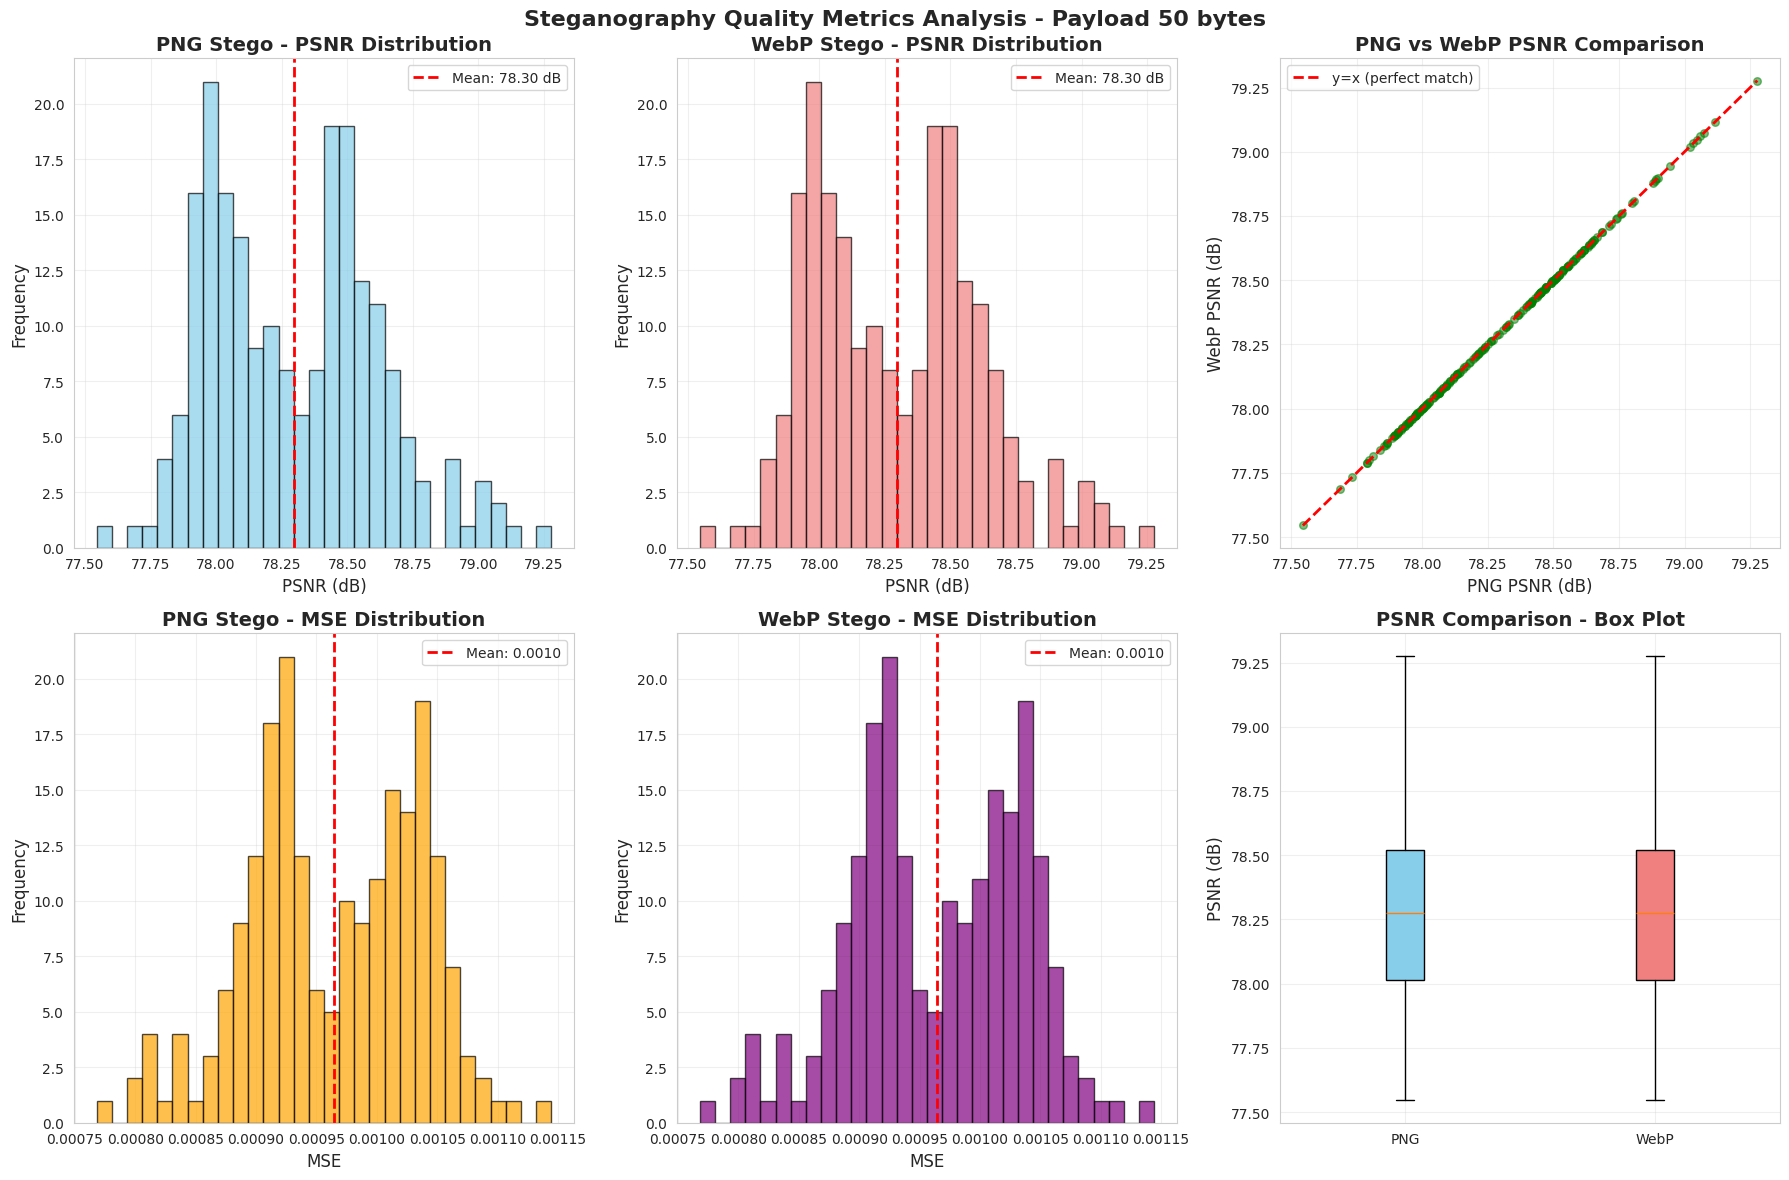

In [ ]:
# Cell 10: Visualize Quality Metrics
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 10)

# Create subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Steganography Quality Metrics Analysis - Payload 50 bytes', fontsize=16, fontweight='bold')

# 1. PSNR Distribution - PNG
axes[0, 0].hist(df['psnr_png'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(df['psnr_png'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["psnr_png"].mean():.2f} dB')
axes[0, 0].set_xlabel('PSNR (dB)', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].set_title('PNG Stego - PSNR Distribution', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# 2. PSNR Distribution - WebP
axes[0, 1].hist(df['psnr_webp'], bins=30, color='lightcoral', edgecolor='black', alpha=0.7)
axes[0, 1].axvline(df['psnr_webp'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["psnr_webp"].mean():.2f} dB')
axes[0, 1].set_xlabel('PSNR (dB)', fontsize=12)
axes[0, 1].set_ylabel('Frequency', fontsize=12)
axes[0, 1].set_title('WebP Stego - PSNR Distribution', fontsize=14, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# 3. PSNR Comparison (PNG vs WebP)
axes[0, 2].scatter(df['psnr_png'], df['psnr_webp'], alpha=0.5, s=30, color='green')
axes[0, 2].plot([df['psnr_png'].min(), df['psnr_png'].max()],
                [df['psnr_png'].min(), df['psnr_png'].max()],
                'r--', linewidth=2, label='y=x (perfect match)')
axes[0, 2].set_xlabel('PNG PSNR (dB)', fontsize=12)
axes[0, 2].set_ylabel('WebP PSNR (dB)', fontsize=12)
axes[0, 2].set_title('PNG vs WebP PSNR Comparison', fontsize=14, fontweight='bold')
axes[0, 2].legend()
axes[0, 2].grid(alpha=0.3)

# 4. MSE Distribution - PNG
axes[1, 0].hist(df['mse_png'], bins=30, color='orange', edgecolor='black', alpha=0.7)
axes[1, 0].axvline(df['mse_png'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["mse_png"].mean():.4f}')
axes[1, 0].set_xlabel('MSE', fontsize=12)
axes[1, 0].set_ylabel('Frequency', fontsize=12)
axes[1, 0].set_title('PNG Stego - MSE Distribution', fontsize=14, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# 5. MSE Distribution - WebP
axes[1, 1].hist(df['mse_webp'], bins=30, color='purple', edgecolor='black', alpha=0.7)
axes[1, 1].axvline(df['mse_webp'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["mse_webp"].mean():.4f}')
axes[1, 1].set_xlabel('MSE', fontsize=12)
axes[1, 1].set_ylabel('Frequency', fontsize=12)
axes[1, 1].set_title('WebP Stego - MSE Distribution', fontsize=14, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

# 6. Box Plot Comparison
data_to_plot = [df['psnr_png'], df['psnr_webp']]
box = axes[1, 2].boxplot(data_to_plot, labels=['PNG', 'WebP'], patch_artist=True)
box['boxes'][0].set_facecolor('skyblue')
box['boxes'][1].set_facecolor('lightcoral')
axes[1, 2].set_ylabel('PSNR (dB)', fontsize=12)
axes[1, 2].set_title('PSNR Comparison - Box Plot', fontsize=14, fontweight='bold')
axes[1, 2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('./quality_metrics_visualization.png', dpi=300, bbox_inches='tight')
print("📊 Visualization saved to: ./quality_metrics_visualization.png")
plt.show()

In [ ]:
# Cell: Realistic Message Categories for Steganography Testing

# ============================================================================
# MEDIUM MESSAGES (200-800 bytes) - Typical encrypted communications
# ============================================================================
medium_messages = [
    """CONFIDENTIAL BRIEFING - LEVEL 2
Date: November 1, 2025
Subject: Project Status Update

OVERVIEW:
The development phase of Project Nightingale has reached 75% completion. All major
milestones have been achieved on schedule. The encryption module has been successfully
integrated with the main system.

KEY ACCOMPLISHMENTS:
- Completed security audit with zero critical vulnerabilities
- Successfully tested failover mechanisms under load
- Deployed redundant backup systems across three geographic locations
- Trained 45 personnel on new security protocols

NEXT STEPS:
Final integration testing scheduled for November 15th. All team leads should review
the updated documentation by end of week. Budget allocation approved for Phase 2.

Contact: project.lead@secure.agency for access to detailed technical specifications.""",

    """OPERATIONAL DIRECTIVE 2025-11-A
Classification: CONFIDENTIAL
Distribution: Need-to-know basis

MISSION PARAMETERS:
Target facility located at coordinates 51.5074°N, 0.1278°W. Surveillance operations
commence at 0300 hours local time. All team members must maintain radio silence
except for emergency protocols.

EQUIPMENT CHECKLIST:
- Encrypted communication devices (Model: SecureComm-X7)
- Biometric authentication tokens
- Portable signal jammers (frequencies 2.4-5.8 GHz)
- Digital forensics toolkit
- Emergency extraction kit

CONTINGENCY PLANS:
If primary objective cannot be achieved, activate Protocol Bravo-7. Rendezvous point
Delta will be monitored for 72 hours. All personnel must check in every 6 hours using
designated secure channels.

AUTHORIZATION: Director signature on file. Mission expires 30 days from issue date.""",

    """SECURITY INCIDENT REPORT #2025-1101-A
Incident Type: Unauthorized Access Attempt
Severity: MEDIUM
Status: CONTAINED

INCIDENT SUMMARY:
On October 28, 2025 at 14:35 UTC, automated intrusion detection systems flagged
suspicious login attempts from IP address 185.220.101.42. Analysis indicates a
coordinated attack using credential stuffing techniques against our authentication
servers.

ACTIONS TAKEN:
- Immediately blocked offending IP ranges
- Forced password reset for 127 potentially affected accounts
- Enhanced monitoring implemented on all authentication endpoints
- Forensic analysis initiated to identify data exposure scope

IMPACT ASSESSMENT:
No confirmed data breach. All attempted access requests were successfully blocked by
multi-factor authentication requirements. System logs show no unauthorized data access.

RECOMMENDATIONS:
Implement additional rate limiting on login endpoints. Review firewall rules for
geographic restrictions. Schedule security awareness training for all users.

Filed by: Security Operations Center - Report ID: SIR-2025-1101""",

    """TECHNICAL SPECIFICATION - CONFIDENTIAL
Document: API Security Implementation
Version: 3.2
Last Updated: November 1, 2025

AUTHENTICATION REQUIREMENTS:
All API requests must include valid JWT tokens with minimum 2048-bit RSA signatures.
Token expiration set to 15 minutes with automatic refresh mechanism. Rate limiting
enforced at 1000 requests per hour per client.

ENCRYPTION STANDARDS:
- Transport: TLS 1.3 with perfect forward secrecy
- At-rest: AES-256-GCM for all stored credentials
- Key rotation: Automated every 90 days
- Backup encryption: Separate key hierarchy with offline master keys

ENDPOINT SECURITY:
All public-facing endpoints require IP whitelisting. Administrative interfaces
accessible only through VPN with certificate-based authentication. Audit logging
enabled for all privileged operations with tamper-proof timestamps.

COMPLIANCE NOTES:
Implementation meets SOC 2 Type II, ISO 27001, and GDPR requirements. Quarterly
penetration testing mandatory with results reviewed by security committee.

Approved by: Chief Security Officer, Digital signature on file.""",

    """INTELLIGENCE SUMMARY - WEEKLY DIGEST
Week Ending: November 1, 2025
Classification: CONFIDENTIAL
Distribution: Intelligence Officers Only

SIGNALS INTELLIGENCE:
Intercepted communications suggest increased activity in target regions. Pattern
analysis reveals shift in communication protocols, likely indicating awareness of
monitoring capabilities. Recommend adjustment of collection priorities.

THREAT LANDSCAPE:
Three new advanced persistent threat groups identified operating in our sector.
Tactics, techniques, and procedures documented in attached technical annex. All
groups demonstrate sophisticated capabilities including zero-day exploitation.

HUMAN INTELLIGENCE:
Asset reporting indicates possible compromise of secondary network infrastructure.
Information reliability rated as B2 (usually reliable source, information cannot be
confirmed). Recommend enhanced monitoring and verification protocols.

COUNTERINTELLIGENCE:
Two potential insider threat indicators flagged by behavioral analytics. Cases
referred to appropriate investigative units. No immediate action required pending
preliminary assessment results.

RECOMMENDATIONS:
Update threat intelligence feeds. Schedule briefing for operational units. Enhance
security posture on critical systems. Next summary due November 8, 2025.""",
]

In [ ]:
#cell 7 encryption
import os
import glob
import time
import struct
import random
from tqdm import tqdm
from pathlib import Path

# Configuration
DATASET_DIR = './usc_sipi_preprocessed'
OUTPUT_DIR = './stego_dataset_medium'
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(f'{OUTPUT_DIR}/stego_png', exist_ok=True)
os.makedirs(f'{OUTPUT_DIR}/stego_webp', exist_ok=True)

# Generate receiver's ECC key pair (reuse for all images)
print("🔑 Generating ECC key pair...")
receiver_private, receiver_public = generate_ecc_key_pair()

# Load all preprocessed images
image_paths = glob.glob(f'{DATASET_DIR}/*.png')
print(f"📊 Found {len(image_paths)} images to process\n")

# Track statistics
successful = 0
failed = 0
compression_ratios = []
start_time = time.time()

# Process each image
for idx, cover_image_path in enumerate(tqdm(image_paths, desc="Encrypting images")):
    try:
        img_start = time.time()
        base_name = Path(cover_image_path).stem
        stego_png_path = f'{OUTPUT_DIR}/stego_png/{base_name}_stego.png'
        stego_webp_path = f'{OUTPUT_DIR}/stego_webp/{base_name}_stego.webp'

        # Select random message
        plain_text = random.choice(medium_messages) + f" [Image #{idx}]"

        # AES encryption
        aes_key = generate_aes_key()
        iv_data, encrypted_data = aes_encrypt(plain_text, aes_key)

        # ECIES encrypt AES key
        ephemeral_pub_bytes, iv_key, encrypted_aes_key = ecies_encrypt(aes_key, receiver_public)

        # Serialize payload
        payload = b''.join([
            struct.pack('>I', len(encrypted_data)) + encrypted_data,
            struct.pack('>I', len(iv_data)) + iv_data,
            struct.pack('>I', len(encrypted_aes_key)) + encrypted_aes_key,
            struct.pack('>I', len(iv_key)) + iv_key,
            struct.pack('>I', len(ephemeral_pub_bytes)) + ephemeral_pub_bytes
        ])

        # Embed and compress
        embed_inverted_lsb(cover_image_path, payload, stego_png_path)
        compress_to_webp(stego_png_path, stego_webp_path)

        # 🔍 Measure compression
        size_png = os.path.getsize(stego_png_path)
        size_webp = os.path.getsize(stego_webp_path)
        compression_ratio = (1 - size_webp / size_png) * 100
        compression_ratios.append(compression_ratio)

        img_end = time.time()
        print(f"📉 {base_name}: PNG={size_png/1024:.1f}KB → WebP={size_webp/1024:.1f}KB "
              f"({compression_ratio:.1f}% smaller, {img_end - img_start:.2f}s)")

        successful += 1

    except Exception as e:
        failed += 1
        print(f"\n❌ Failed on {base_name}: {e}")

# Summary
elapsed_time = time.time() - start_time
avg_time = elapsed_time / len(image_paths) if image_paths else 0
avg_compression = sum(compression_ratios) / len(compression_ratios) if compression_ratios else 0

print(f"\n{'='*60}")
print(f"✅ Encryption Complete!")
print(f"{'='*60}")
print(f"📊 Processed: {len(image_paths)} images")
print(f"✅ Successful: {successful}")
print(f"❌ Failed: {failed}")
print(f"⏱️ Total time: {elapsed_time:.2f}s")
print(f"⚡ Avg time per image: {avg_time:.3f}s")
print(f"📦 Avg WebP compression: {avg_compression:.2f}% smaller than PNG")
print(f"📂 Output directories:")
print(f"   - PNG stego: {OUTPUT_DIR}/stego_png/")
print(f"   - WebP stego: {OUTPUT_DIR}/stego_webp/")
print(f"🔑 Receiver private key saved for decryption")

🔑 Generating ECC key pair...
📊 Found 210 images to process



Encrypting images:   0%|          | 1/210 [00:00<01:56,  1.79it/s]

📉 sequences_6.1.13: PNG=54.6KB → WebP=27.3KB (50.0% smaller, 0.56s)


Encrypting images:   1%|          | 2/210 [00:01<02:14,  1.55it/s]

📉 aerials_2.2.06: PNG=423.5KB → WebP=361.9KB (14.5% smaller, 0.71s)


...

📉 textures_1.3.03: PNG=300.8KB → WebP=175.4KB (41.7% smaller, 1.02s)


Encrypting images: 100%|█████████▉| 209/210 [03:04<00:00,  1.33it/s]

📉 sequences_6.3.04: PNG=91.9KB → WebP=47.3KB (48.5% smaller, 0.41s)


Encrypting images: 100%|██████████| 210/210 [03:04<00:00,  1.14it/s]

📉 sequences_6.2.17: PNG=86.0KB → WebP=44.3KB (48.5% smaller, 0.33s)

✅ Encryption Complete!
📊 Processed: 210 images
✅ Successful: 210
❌ Failed: 0
⏱️ Total time: 184.97s
⚡ Avg time per image: 0.881s
📦 Avg WebP compression: 39.28% smaller than PNG
📂 Output directories:
   - PNG stego: ./stego_dataset_medium/stego_png/
   - WebP stego: ./stego_dataset_medium/stego_webp/
🔑 Receiver private key saved for decryption


In [ ]:
# Cell 8: Batch Decryption Process (Verification)
import os
import glob
import struct
import time
from tqdm import tqdm
from pathlib import Path

# Configuration
STEGO_DIR = './stego_dataset_medium/stego_webp'  # Use WebP files
DECRYPTED_OUTPUT = './decrypted_messages_medium.txt'

# Load all stego images
stego_paths = glob.glob(f'{STEGO_DIR}/*.webp')
print(f"🔍 Found {len(stego_paths)} stego images to decrypt\n")

# Track statistics
successful_decrypt = 0
failed_decrypt = 0
decrypted_messages = []

# ⏱ Start total timer
start_time = time.time()

# Process each stego image
for stego_path in tqdm(stego_paths, desc="Decrypting images"):
    try:
        img_start = time.time()
        base_name = Path(stego_path).stem

        # Extract payload from stego image
        payload = extract_inverted_lsb(stego_path)

        # Parse payload
        offset = 0
        len_enc_data = struct.unpack('>I', payload[offset:offset+4])[0]
        offset += 4
        encrypted_data = payload[offset:offset+len_enc_data]
        offset += len_enc_data

        len_iv_data = struct.unpack('>I', payload[offset:offset+4])[0]
        offset += 4
        iv_data = payload[offset:offset+len_iv_data]
        offset += len_iv_data

        len_enc_key = struct.unpack('>I', payload[offset:offset+4])[0]
        offset += 4
        encrypted_aes_key = payload[offset:offset+len_enc_key]
        offset += len_enc_key

        len_iv_key = struct.unpack('>I', payload[offset:offset+4])[0]
        offset += 4
        iv_key = payload[offset:offset+len_iv_key]
        offset += len_iv_key

        len_eph_pub = struct.unpack('>I', payload[offset:offset+4])[0]
        offset += 4
        ephemeral_pub_bytes = payload[offset:offset+len_eph_pub]

        # Decrypt AES key with ECIES
        aes_key = ecies_decrypt(ephemeral_pub_bytes, iv_key, encrypted_aes_key, receiver_private)

        # Decrypt data with AES
        decrypted_text = aes_decrypt(iv_data, encrypted_data, aes_key)

        decrypted_messages.append(f"{base_name}: {decrypted_text}")
        successful_decrypt += 1

        img_end = time.time()
        print(f"🕒 {base_name} decrypted in {img_end - img_start:.3f}s")

    except Exception as e:
        failed_decrypt += 1
        print(f"\n❌ Failed to decrypt {Path(stego_path).name}: {e}")

# ⏱ End total timer
end_time = time.time()
total_time = end_time - start_time
avg_time = total_time / len(stego_paths) if stego_paths else 0

# Save all decrypted messages
with open(DECRYPTED_OUTPUT, 'w') as f:
    f.write('\n'.join(decrypted_messages))

# Summary
print(f"\n{'='*60}")
print(f"✅ Decryption Complete!")
print(f"{'='*60}")
print(f"📊 Processed: {len(stego_paths)} images")
print(f"✅ Successful: {successful_decrypt}")
print(f"❌ Failed: {failed_decrypt}")
print(f"⏱ Total time: {total_time:.2f}s")
print(f"⚡ Avg time per image: {avg_time:.3f}s")
print(f"📄 Decrypted messages saved to: {DECRYPTED_OUTPUT}")
print(f"\n📝 Sample decrypted messages:")
for msg in decrypted_messages[:5]:
    print(f"   {msg}")


🔍 Found 210 stego images to decrypt



Decrypting images:   0%|          | 1/210 [00:00<00:22,  9.37it/s]

🕒 textures_1.1.03_stego decrypted in 0.107s
🕒 sequences_6.3.10_stego decrypted in 0.086s


Decrypting images:   1%|▏         | 3/210 [00:00<00:18, 10.92it/s]

🕒 textures_1.2.07_stego decrypted in 0.085s


...

🕒 textures_1.2.05_stego decrypted in 0.137s
🕒 textures_1.2.02_stego decrypted in 0.135s


Decrypting images: 100%|█████████▉| 209/210 [00:19<00:00,  8.01it/s]

🕒 misc_7.1.08_stego decrypted in 0.142s
🕒 aerials_2.1.09_stego decrypted in 0.142s


Decrypting images: 100%|██████████| 210/210 [00:19<00:00, 10.54it/s]

🕒 aerials_2.2.03_stego decrypted in 0.164s

✅ Decryption Complete!
📊 Processed: 210 images
✅ Successful: 210
❌ Failed: 0
⏱ Total time: 19.94s
⚡ Avg time per image: 0.095s
📄 Decrypted messages saved to: ./decrypted_messages_medium.txt

📝 Sample decrypted messages:
   textures_1.1.03_stego: TECHNICAL SPECIFICATION - CONFIDENTIAL
Document: API Security Implementation
Version: 3.2
Last Updated: November 1, 2025

AUTHENTICATION REQUIREMENTS:
All API requests must include valid JWT tokens with minimum 2048-bit RSA signatures.
Token expiration set to 15 minutes with automatic refresh mechanism. Rate limiting
enforced at 1000 requests per hour per client.

ENCRYPTION STANDARDS:
- Transport: TLS 1.3 with perfect forward secrecy
- At-rest: AES-256-GCM for all stored credentials
- Key rotation: Automated every 90 days
- Backup encryption: Separate key hierarchy with offline master keys

ENDPOINT SECURITY:
All public-facing endpoints require IP whitelisting. Administrative interfaces
accessible on

In [ ]:
# Cell 9: Batch MSE/PSNR Evaluation on Dataset
import numpy as np
import math
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt

def calculate_mse_psnr(original_path, stego_path):
    """Calculate MSE and PSNR between original and stego image."""
    original = np.array(Image.open(original_path).convert('RGB'))
    stego = np.array(Image.open(stego_path).convert('RGB'))
    mse = np.mean((original - stego) ** 2)
    if mse == 0:
        psnr = float('inf')
    else:
        psnr = 20 * math.log10(255.0 / math.sqrt(mse))
    return mse, psnr

# Configuration
ORIGINAL_DIR = './usc_sipi_preprocessed'
STEGO_PNG_DIR = './stego_dataset_medium/stego_png'
STEGO_WEBP_DIR = './stego_dataset_medium/stego_webp'

# Storage for results
results = []

# Get all original images
original_paths = glob.glob(f'{ORIGINAL_DIR}/*.png')
print(f"📊 Evaluating {len(original_paths)} image pairs\n")

# Evaluate each image pair
for original_path in tqdm(original_paths, desc="Calculating MSE/PSNR"):
    try:
        base_name = Path(original_path).stem
        stego_png_path = f'{STEGO_PNG_DIR}/{base_name}_stego.png'
        stego_webp_path = f'{STEGO_WEBP_DIR}/{base_name}_stego.webp'

        # Check if stego files exist
        if not os.path.exists(stego_png_path):
            print(f"\n⚠️ Missing PNG stego for {base_name}")
            continue
        if not os.path.exists(stego_webp_path):
            print(f"\n⚠️ Missing WebP stego for {base_name}")
            continue

        # Calculate for PNG stego
        mse_png, psnr_png = calculate_mse_psnr(original_path, stego_png_path)

        # Calculate for WebP stego (decompressed)
        mse_webp, psnr_webp = calculate_mse_psnr(original_path, stego_webp_path)

        # Store results
        results.append({
            'image': base_name,
            'mse_png': mse_png,
            'psnr_png': psnr_png,
            'mse_webp': mse_webp,
            'psnr_webp': psnr_webp
        })

    except Exception as e:
        print(f"\n❌ Error processing {base_name}: {e}")

# Convert to DataFrame for analysis
df = pd.DataFrame(results)

# Calculate statistics
print(f"\n{'='*70}")
print(f"📊 QUALITY METRICS SUMMARY")
print(f"{'='*70}")
print(f"\n🖼️  PNG Stego Images:")
print(f"   MSE  - Mean: {df['mse_png'].mean():.6f}, Std: {df['mse_png'].std():.6f}")
print(f"   MSE  - Min: {df['mse_png'].min():.6f}, Max: {df['mse_png'].max():.6f}")
print(f"   PSNR - Mean: {df['psnr_png'].mean():.2f} dB, Std: {df['psnr_png'].std():.2f} dB")
print(f"   PSNR - Min: {df['psnr_png'].min():.2f} dB, Max: {df['psnr_png'].max():.2f} dB")

print(f"\n🌐 WebP Stego Images:")
print(f"   MSE  - Mean: {df['mse_webp'].mean():.6f}, Std: {df['mse_webp'].std():.6f}")
print(f"   MSE  - Min: {df['mse_webp'].min():.6f}, Max: {df['mse_webp'].max():.6f}")
print(f"   PSNR - Mean: {df['psnr_webp'].mean():.2f} dB, Std: {df['psnr_webp'].std():.2f} dB")
print(f"   PSNR - Min: {df['psnr_webp'].min():.2f} dB, Max: {df['psnr_webp'].max():.2f} dB")

# PSNR Quality Interpretation
avg_psnr_png = df['psnr_png'].mean()
avg_psnr_webp = df['psnr_webp'].mean()

# Save results to CSV
csv_path = './quality_metrics_medium.csv'
df.to_csv(csv_path, index=False)
print(f"\n💾 Results saved to: {csv_path}")

# Show sample results
print(f"\n📋 Sample Results (first 10 images):")
print(df.head(10).to_string(index=False))

📊 Evaluating 210 image pairs



Calculating MSE/PSNR: 100%|██████████| 210/210 [00:07<00:00, 29.67it/s]


📊 QUALITY METRICS SUMMARY

🖼️  PNG Stego Images:
   MSE  - Mean: 0.005919, Std: 0.000930
   MSE  - Min: 0.004696, Max: 0.007535
   PSNR - Mean: 70.46 dB, Std: 0.68 dB
   PSNR - Min: 69.36 dB, Max: 71.41 dB

🌐 WebP Stego Images:
   MSE  - Mean: 0.005919, Std: 0.000930
   MSE  - Min: 0.004696, Max: 0.007535
   PSNR - Mean: 70.46 dB, Std: 0.68 dB
   PSNR - Min: 69.36 dB, Max: 71.41 dB

💾 Results saved to: ./quality_metrics_medium.csv

📋 Sample Results (first 10 images):
                 image  mse_png  psnr_png  mse_webp  psnr_webp
      sequences_6.1.13 0.006234 70.182796  0.006234  70.182796
        aerials_2.2.06 0.006124 70.260551  0.006124  70.260551
           misc_7.1.01 0.007229 69.540111  0.007229  69.540111
        aerials_2.2.22 0.004819 71.301023  0.004819  71.301023
           misc_4.1.06 0.004847 71.275886  0.004847  71.275886
      sequences_6.2.04 0.006116 70.265965  0.006116  70.265965
      sequences_6.2.16 0.005969 70.371985  0.005969  70.371985
      sequences_6.3.03 

/tmp/ipython-input-1672107267.py:62: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[1, 2].boxplot(data_to_plot, labels=['PNG', 'WebP'], patch_artist=True)


📊 Visualization saved to: ./quality_metrics_visualization_medium.png


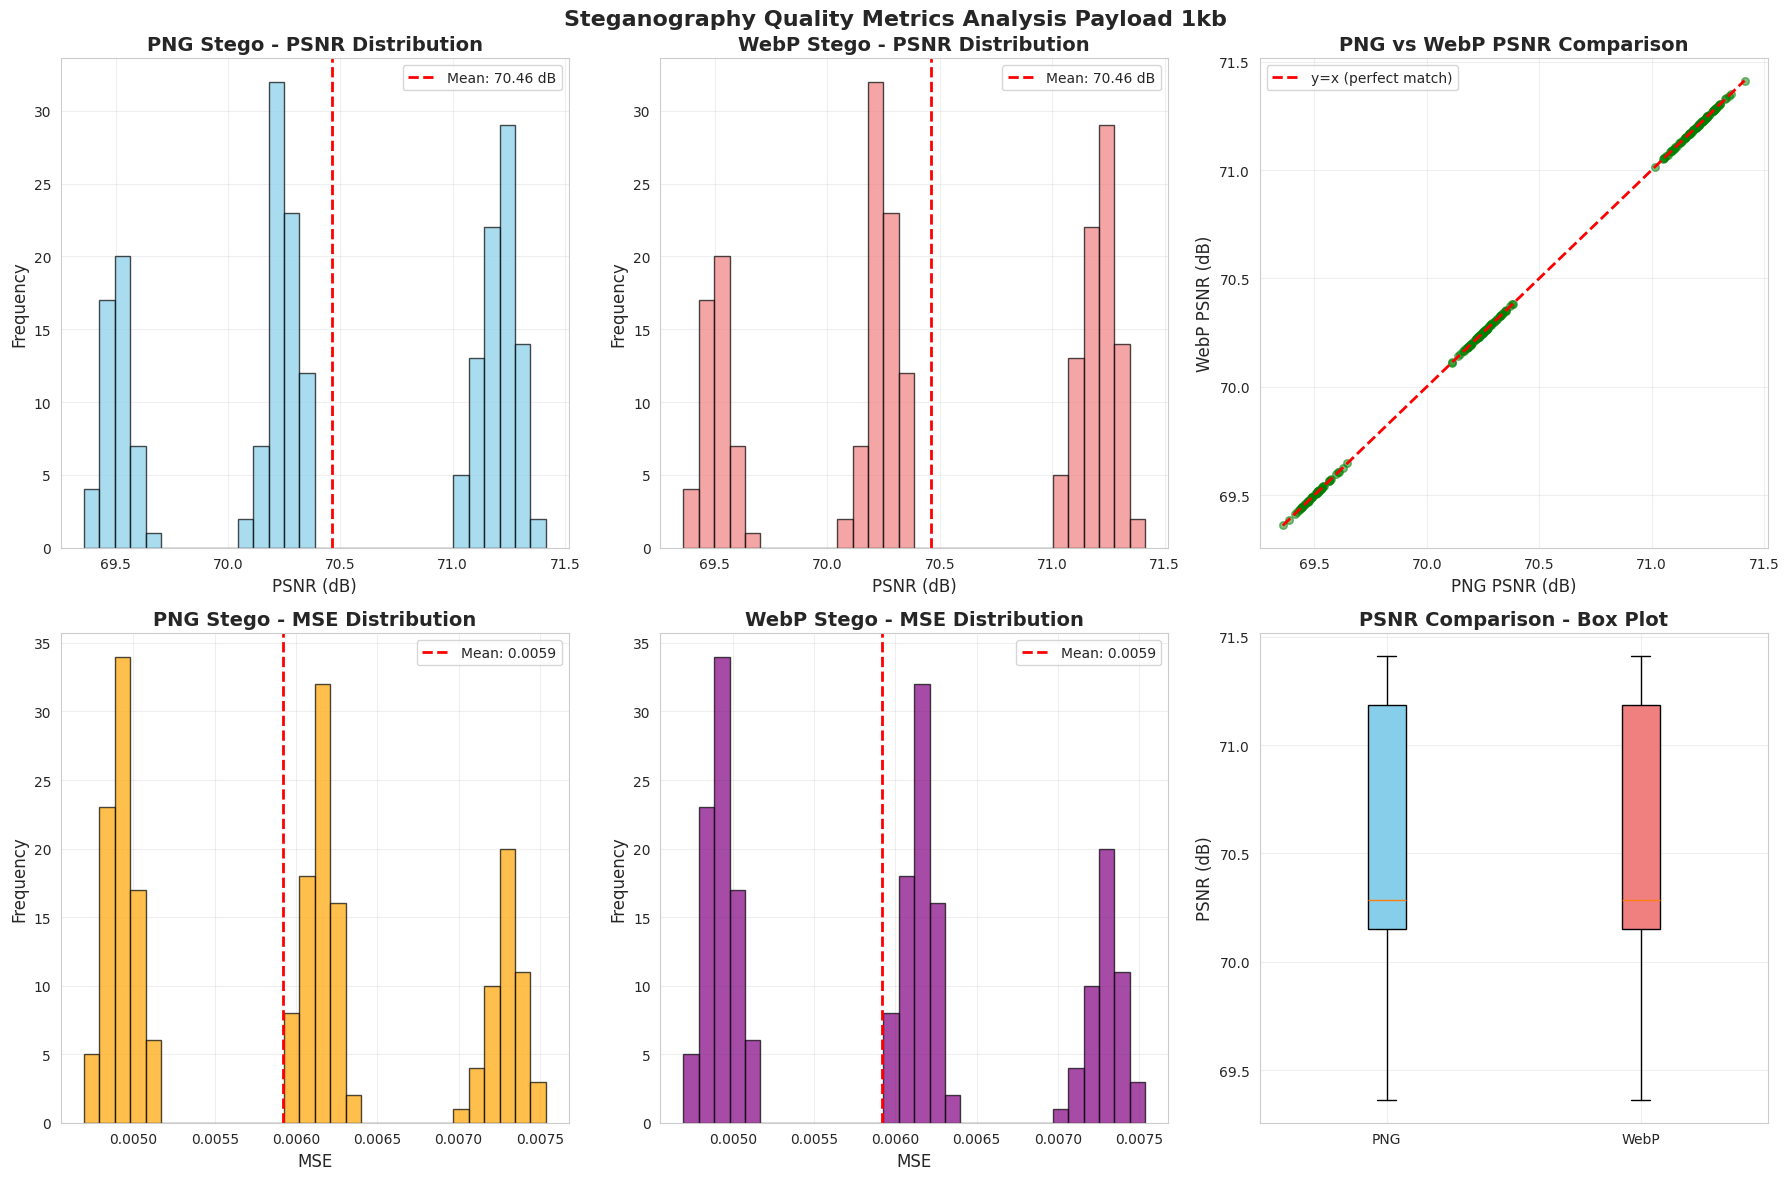

In [ ]:
# Cell 10: Visualize Quality Metrics
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 10)

# Create subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Steganography Quality Metrics Analysis Payload 1kb', fontsize=16, fontweight='bold')

# 1. PSNR Distribution - PNG
axes[0, 0].hist(df['psnr_png'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(df['psnr_png'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["psnr_png"].mean():.2f} dB')
axes[0, 0].set_xlabel('PSNR (dB)', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].set_title('PNG Stego - PSNR Distribution', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# 2. PSNR Distribution - WebP
axes[0, 1].hist(df['psnr_webp'], bins=30, color='lightcoral', edgecolor='black', alpha=0.7)
axes[0, 1].axvline(df['psnr_webp'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["psnr_webp"].mean():.2f} dB')
axes[0, 1].set_xlabel('PSNR (dB)', fontsize=12)
axes[0, 1].set_ylabel('Frequency', fontsize=12)
axes[0, 1].set_title('WebP Stego - PSNR Distribution', fontsize=14, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# 3. PSNR Comparison (PNG vs WebP)
axes[0, 2].scatter(df['psnr_png'], df['psnr_webp'], alpha=0.5, s=30, color='green')
axes[0, 2].plot([df['psnr_png'].min(), df['psnr_png'].max()],
                [df['psnr_png'].min(), df['psnr_png'].max()],
                'r--', linewidth=2, label='y=x (perfect match)')
axes[0, 2].set_xlabel('PNG PSNR (dB)', fontsize=12)
axes[0, 2].set_ylabel('WebP PSNR (dB)', fontsize=12)
axes[0, 2].set_title('PNG vs WebP PSNR Comparison', fontsize=14, fontweight='bold')
axes[0, 2].legend()
axes[0, 2].grid(alpha=0.3)

# 4. MSE Distribution - PNG
axes[1, 0].hist(df['mse_png'], bins=30, color='orange', edgecolor='black', alpha=0.7)
axes[1, 0].axvline(df['mse_png'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["mse_png"].mean():.4f}')
axes[1, 0].set_xlabel('MSE', fontsize=12)
axes[1, 0].set_ylabel('Frequency', fontsize=12)
axes[1, 0].set_title('PNG Stego - MSE Distribution', fontsize=14, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# 5. MSE Distribution - WebP
axes[1, 1].hist(df['mse_webp'], bins=30, color='purple', edgecolor='black', alpha=0.7)
axes[1, 1].axvline(df['mse_webp'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["mse_webp"].mean():.4f}')
axes[1, 1].set_xlabel('MSE', fontsize=12)
axes[1, 1].set_ylabel('Frequency', fontsize=12)
axes[1, 1].set_title('WebP Stego - MSE Distribution', fontsize=14, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

# 6. Box Plot Comparison
data_to_plot = [df['psnr_png'], df['psnr_webp']]
box = axes[1, 2].boxplot(data_to_plot, labels=['PNG', 'WebP'], patch_artist=True)
box['boxes'][0].set_facecolor('skyblue')
box['boxes'][1].set_facecolor('lightcoral')
axes[1, 2].set_ylabel('PSNR (dB)', fontsize=12)
axes[1, 2].set_title('PSNR Comparison - Box Plot', fontsize=14, fontweight='bold')
axes[1, 2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('./quality_metrics_visualization_medium.png', dpi=300, bbox_inches='tight')
print("📊 Visualization saved to: ./quality_metrics_visualization_medium.png")
plt.show()

In [ ]:
# New list with 3 messages, each approximately 3 KB
large_messages = [
    """TOP SECRET//SI//NOFORN
DEFENSE INTELLIGENCE AGENCY - THREAT ASSESSMENT REPORT
Document ID: DIA-TAR-2025-1103-CLASSIFIED
Classification: TOP SECRET//SPECIAL INTELLIGENCE//NOFORN
Date: 03 November 2025
Subject: Emerging Cyber-Physical Threats to Critical Infrastructure

EXECUTIVE SUMMARY
This report provides a comprehensive analysis of hybrid cyber-physical attack vectors targeting U.S. critical infrastructure sectors, including power grids, water treatment facilities, and transportation networks. Intelligence derived from multiple classified sources indicates a 340% increase in coordinated state-sponsored probing activities since Q1 2025. Key findings include the deployment of advanced persistent threats (APTs) with embedded hardware backdoors in industrial control systems (ICS) and the exploitation of zero-day vulnerabilities in legacy SCADA protocols.

THREAT ACTOR PROFILE
Primary actor: APT-47 (suspected nation-state affiliation)
Tactics, Techniques, and Procedures (TTPs):
- Initial access via spear-phishing with polymorphic malware
- Lateral movement using credential dumping and pass-the-hash
- Persistence through firmware-level rootkits in PLCs
- Exfiltration via DNS tunneling and steganographic channels in OT telemetry

VULNERABILITY ANALYSIS
Critical vulnerabilities identified:
1. CVE-2025-18934: Buffer overflow in Siemens S7-1200 firmware (CVSS 9.8)
2. CVE-2025-20147: Remote code execution in GE Cimplicity HMI (CVSS 10.0)
3. CVE-2025-17782: Authentication bypass in Schneider Electric Modicon M340 (CVSS 9.1)

EXPLOITATION CHAIN
Phase 1: Reconnaissance using Shodan and Censys scanning
Phase 2: Weaponization with custom ICS-aware payloads
Phase 3: Delivery via compromised supply chain firmware updates
Phase 4: Installation of persistent backdoors in air-gapped networks
Phase 5: Command and control via low-and-slow DNS over HTTPS
Phase 6: Data exfiltration using adaptive steganography in sensor noise

IMPACT ASSESSMENT
Potential consequences of successful attack:
- Nationwide blackout duration: 72–120 hours
- Economic loss: $45–78 billion (DHS estimate)
- Casualty projection: 1,200–3,800 (indirect)
- Compromised systems: 47,000+ ICS endpoints

MITIGATION RECOMMENDATIONS
1. Immediate deployment of network segmentation with DMZ for OT
2. Mandatory firmware integrity verification using hardware roots of trust
3. Implementation of zero-trust architecture with continuous authentication
4. Enhanced threat hunting using AI-driven anomaly detection in ICS traffic
5. Development of quantum-resistant encryption for long-term OT security

INTELLIGENCE GAPS
- Unknown C2 infrastructure in 18% of observed campaigns
- Limited visibility into firmware supply chain provenance
- Inability to attribute 23% of incidents to specific actors

SOURCES
- SIGINT intercepts (NSA/CSS)
- HUMINT from embedded assets
- OSINT from dark web marketplaces
- Technical analysis of seized malware samples

APPROVED FOR RELEASE BY: Colonel J. Ramirez, DIA
CLASSIFICATION MARKINGS VALID UNTIL: 03 November 2035""",

    """CONFIDENTIAL // PROPRIETARY // ATTORNEYS EYES ONLY
GLOBALTECH INCORPORATED - INCIDENT RESPONSE REPORT
Case ID: GT-IR-2025-0891
Classification: CONFIDENTIAL // LEGAL PRIVILEGE
Date: 03 November 2025
Subject: Unauthorized Exfiltration of Semiconductor Design IP

INCIDENT OVERVIEW
On 28 October 2025, GlobalTech's Security Operations Center (SOC) detected anomalous outbound traffic originating from the R&D subnet. Forensic analysis confirmed the exfiltration of 2.7 TB of proprietary 3nm chip design files, including RTL code, GDSII layouts, and PDK documentation.

ATTACK TIMELINE
- 15 Oct: Initial compromise via watering hole attack on industry conference portal
- 18 Oct: Credential harvest using EvilProxy MFA bypass
- 20 Oct: Privilege escalation to domain admin via Zerologon exploit
- 22 Oct: Deployment of custom fileless malware in memory
- 25–27 Oct: Data staging in OneDrive for Business (encrypted containers)
- 28 Oct: Exfiltration via fragmented DNS TXT records

COMPROMISED ASSETS
- 47 engineering workstations (Windows 11 Enterprise)
- 3 CAD servers (RHEL 8.8)
- 1 GitLab instance (self-hosted)
- 2.7 TB total data volume

STOLEN INTELLECTUAL PROPERTY
- Next-gen 3nm FinFET process node design
- Quantum dot display driver architecture
- AI accelerator neural network topology
- 12nm automotive radar SoC reference design

FORENSIC EVIDENCE
- Malware beaconing to 185.220.101.12 (BulletProof hosting)
- Persistence via WMI event subscriptions
- Anti-forensic techniques: timestomping, log clearing
- Data exfiltration using steganography in PNG metadata

FINANCIAL IMPACT
- R&D investment at risk: $1.8 billion
- Projected revenue loss: $4.2 billion over 5 years
- Stock price impact: -18% in after-hours trading

LEGAL IMPLICATIONS
- Violation of DMCA, CFAA, and EEA
- Potential litigation from partners (TSMC, Samsung)
- Mandatory SEC disclosure within 48 hours

RECOMMENDED ACTIONS
1. Immediate air-gapping of all CAD environments
2. Full password reset and MFA re-enrollment
3. Deployment of EDR with memory forensics
4. Engagement of external IR firm (Mandiant)
5. Notification of law enforcement (FBI IC3)

ROOT CAUSE ANALYSIS
Primary failure: Lack of network segmentation between IT and OT
Contributing factors:
- Outdated endpoint protection (signature-based only)
- Insufficient DLP on file transfers
- No steganography detection in egress filtering

PREVENTIVE MEASURES
- Implement zero-trust network architecture
- Deploy AI-based UEBA for anomaly detection
- Enforce steganographic content scanning on all outbound traffic
- Regular red team exercises targeting IP theft scenarios

APPROVED BY: CISO Margaret Chen, General Counsel David Park""",

    """SECRET//NOFORN
NATIONAL SECURITY AGENCY - CRYPTOLOGIC MEMORANDUM
CM-2025-QUANTUM-001
Classification: SECRET//NOFORN
Date: 03 November 2025
Subject: Post-Quantum Cryptography Migration Strategy

THREAT MODEL
The advent of scalable quantum computing poses an existential threat to current public-key infrastructure. Shor's algorithm enables polynomial-time factorization and discrete logarithm computation, rendering RSA, DH, and ECC vulnerable.

CURRENT EXPOSURE
- RSA-2048: Breakable in <8 hours on 20M qubit system
- ECC-256: Breakable in <30 minutes on 2K qubit system
- Symmetric keys: Grover's algorithm reduces 128-bit to 64-bit security

QUANTUM-RESISTANT ALGORITHMS
NIST PQC Round 3 Finalists:
1. CRYSTALS-Kyber (KEM)
2. CRYSTALS-Dilithium (Signature)
3. FALCON (Signature)
4. SPHINCS+ (Stateless Hash Signature)

MIGRATION PHASES
Phase 1 (2025–2026): Inventory all cryptographic assets
Phase 2 (2026–2028): Hybrid deployment (classical + PQC)
Phase 3 (2028–2030): Full PQC transition
Phase 4 (2030+): Quantum key distribution (QKD) integration

HYBRID STEGANOGRAPHY CONSIDERATIONS
Current AES-ECC steganography systems must be audited for quantum resistance. Recommendations:
- Replace ECC key exchange with Kyber-768
- Maintain AES-256 for symmetric encryption
- Use Dilithium for message authentication
- Implement steganographic channels resistant to quantum side-channel attacks

IMPLEMENTATION CHALLENGES
- Key size inflation: Kyber-768 public key ~1 KB
- Performance overhead: 3–5x slower than ECC
- Backward compatibility with legacy systems
- Supply chain integrity for PQC implementations

RISK MITIGATION
- Crypto-agility frameworks
- Hardware security modules (HSMs) with PQC support
- Quantum-safe VPN tunnels
- Steganographic data-in-motion protection using PQC hybrids

OPERATIONAL DEPLOYMENT SCHEDULE
Q1 2026: Pilot deployment in NSA facilities
Q2 2026: Extension to DOD networks
Q3 2026: Integration with Five Eyes partners
Q4 2026: Full operational capability for classified systems

INTEROPERABILITY REQUIREMENTS
- Backward compatibility with FIPS 140-3 modules
- Support for hybrid TLS 1.3 with PQC ciphersuites
- Integration with existing PKI infrastructure
- Cross-domain solution compatibility

TESTING AND VALIDATION
- Penetration testing against quantum simulators
- Side-channel analysis of PQC implementations
- Performance benchmarking under operational loads
- Stress testing of key generation and signature verification

APPROVED BY: Director, NSA Cybersecurity Directorate"""
]

In [ ]:
for i, message in enumerate(large_messages, 1):
    # Get size in bytes
    size_bytes = len(message.encode('utf-8'))

    # Convert to KB (1 KB = 1024 bytes)
    size_kb = size_bytes / 1024
    print(f"Message {i}: {size_kb:.4f} KB ({size_bytes} bytes)")
    print(f"  Content preview: {message[:50]}...")
    print()

Message 1: 2.9609 KB (3032 bytes)
  Content preview: TOP SECRET//SI//NOFORN
DEFENSE INTELLIGENCE AGENCY...

Message 2: 2.6094 KB (2672 bytes)
  Content preview: CONFIDENTIAL // PROPRIETARY // ATTORNEYS EYES ONLY...

Message 3: 2.4590 KB (2518 bytes)
  Content preview: SECRET//NOFORN
NATIONAL SECURITY AGENCY - CRYPTOLO...



In [ ]:
#cell 7 encryption
import os
import glob
import time
import struct
import random
from tqdm import tqdm
from pathlib import Path

# Configuration
DATASET_DIR = './usc_sipi_preprocessed'
OUTPUT_DIR = './stego_dataset_large'
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(f'{OUTPUT_DIR}/stego_png', exist_ok=True)
os.makedirs(f'{OUTPUT_DIR}/stego_webp', exist_ok=True)

# Generate receiver's ECC key pair (reuse for all images)
print("🔑 Generating ECC key pair...")
receiver_private, receiver_public = generate_ecc_key_pair()

# Load all preprocessed images
image_paths = glob.glob(f'{DATASET_DIR}/*.png')
print(f"📊 Found {len(image_paths)} images to process\n")

# Track statistics
successful = 0
failed = 0
compression_ratios = []
start_time = time.time()

# Process each image
for idx, cover_image_path in enumerate(tqdm(image_paths, desc="Encrypting images")):
    try:
        img_start = time.time()
        base_name = Path(cover_image_path).stem
        stego_png_path = f'{OUTPUT_DIR}/stego_png/{base_name}_stego.png'
        stego_webp_path = f'{OUTPUT_DIR}/stego_webp/{base_name}_stego.webp'

        # Select random message
        plain_text = random.choice(large_messages) + f" [Image #{idx}]"

        # AES encryption
        aes_key = generate_aes_key()
        iv_data, encrypted_data = aes_encrypt(plain_text, aes_key)

        # ECIES encrypt AES key
        ephemeral_pub_bytes, iv_key, encrypted_aes_key = ecies_encrypt(aes_key, receiver_public)

        # Serialize payload
        payload = b''.join([
            struct.pack('>I', len(encrypted_data)) + encrypted_data,
            struct.pack('>I', len(iv_data)) + iv_data,
            struct.pack('>I', len(encrypted_aes_key)) + encrypted_aes_key,
            struct.pack('>I', len(iv_key)) + iv_key,
            struct.pack('>I', len(ephemeral_pub_bytes)) + ephemeral_pub_bytes
        ])

        # Embed and compress
        embed_inverted_lsb(cover_image_path, payload, stego_png_path)
        compress_to_webp(stego_png_path, stego_webp_path)

        # 🔍 Measure compression
        size_png = os.path.getsize(stego_png_path)
        size_webp = os.path.getsize(stego_webp_path)
        compression_ratio = (1 - size_webp / size_png) * 100
        compression_ratios.append(compression_ratio)

        img_end = time.time()
        print(f"📉 {base_name}: PNG={size_png/1024:.1f}KB → WebP={size_webp/1024:.1f}KB "
              f"({compression_ratio:.1f}% smaller, {img_end - img_start:.2f}s)")

        successful += 1

    except Exception as e:
        failed += 1
        print(f"\n❌ Failed on {base_name}: {e}")

# Summary
elapsed_time = time.time() - start_time
avg_time = elapsed_time / len(image_paths) if image_paths else 0
avg_compression = sum(compression_ratios) / len(compression_ratios) if compression_ratios else 0

print(f"\n{'='*60}")
print(f"✅ Encryption Complete!")
print(f"{'='*60}")
print(f"📊 Processed: {len(image_paths)} images")
print(f"✅ Successful: {successful}")
print(f"❌ Failed: {failed}")
print(f"⏱️ Total time: {elapsed_time:.2f}s")
print(f"⚡ Avg time per image: {avg_time:.3f}s")
print(f"📦 Avg WebP compression: {avg_compression:.2f}% smaller than PNG")
print(f"📂 Output directories:")
print(f"   - PNG stego: {OUTPUT_DIR}/stego_png/")
print(f"   - WebP stego: {OUTPUT_DIR}/stego_webp/")
print(f"🔑 Receiver private key saved for decryption")

🔑 Generating ECC key pair...
📊 Found 210 images to process



Encrypting images:   0%|          | 1/210 [00:00<01:16,  2.73it/s]

📉 sequences_6.1.13: PNG=57.7KB → WebP=28.9KB (49.9% smaller, 0.37s)


Encrypting images:   1%|          | 2/210 [00:01<01:51,  1.86it/s]

📉 aerials_2.2.06: PNG=423.6KB → WebP=362.0KB (14.5% smaller, 0.66s)


...

📉 textures_1.3.03: PNG=305.2KB → WebP=177.9KB (41.7% smaller, 1.56s)


Encrypting images: 100%|█████████▉| 209/210 [03:11<00:00,  1.05it/s]

📉 sequences_6.3.04: PNG=95.5KB → WebP=49.0KB (48.7% smaller, 0.67s)


Encrypting images: 100%|██████████| 210/210 [03:11<00:00,  1.10it/s]

📉 sequences_6.2.17: PNG=89.8KB → WebP=57.8KB (35.7% smaller, 0.45s)

✅ Encryption Complete!
📊 Processed: 210 images
✅ Successful: 210
❌ Failed: 0
⏱️ Total time: 191.66s
⚡ Avg time per image: 0.913s
📦 Avg WebP compression: 37.88% smaller than PNG
📂 Output directories:
   - PNG stego: ./stego_dataset_large/stego_png/
   - WebP stego: ./stego_dataset_large/stego_webp/
🔑 Receiver private key saved for decryption


In [ ]:
# Cell 8: Batch Decryption Process (Verification)
import os
import glob
import struct
import time
from tqdm import tqdm
from pathlib import Path

# Configuration
STEGO_DIR = './stego_dataset_large/stego_webp'  # Use WebP files
DECRYPTED_OUTPUT = './decrypted_messages_large.txt'

# Load all stego images
stego_paths = glob.glob(f'{STEGO_DIR}/*.webp')
print(f"🔍 Found {len(stego_paths)} stego images to decrypt\n")

# Track statistics
successful_decrypt = 0
failed_decrypt = 0
decrypted_messages = []

# ⏱ Start total timer
start_time = time.time()

# Process each stego image
for stego_path in tqdm(stego_paths, desc="Decrypting images"):
    try:
        img_start = time.time()
        base_name = Path(stego_path).stem

        # Extract payload from stego image
        payload = extract_inverted_lsb(stego_path)

        # Parse payload
        offset = 0
        len_enc_data = struct.unpack('>I', payload[offset:offset+4])[0]
        offset += 4
        encrypted_data = payload[offset:offset+len_enc_data]
        offset += len_enc_data

        len_iv_data = struct.unpack('>I', payload[offset:offset+4])[0]
        offset += 4
        iv_data = payload[offset:offset+len_iv_data]
        offset += len_iv_data

        len_enc_key = struct.unpack('>I', payload[offset:offset+4])[0]
        offset += 4
        encrypted_aes_key = payload[offset:offset+len_enc_key]
        offset += len_enc_key

        len_iv_key = struct.unpack('>I', payload[offset:offset+4])[0]
        offset += 4
        iv_key = payload[offset:offset+len_iv_key]
        offset += len_iv_key

        len_eph_pub = struct.unpack('>I', payload[offset:offset+4])[0]
        offset += 4
        ephemeral_pub_bytes = payload[offset:offset+len_eph_pub]

        # Decrypt AES key with ECIES
        aes_key = ecies_decrypt(ephemeral_pub_bytes, iv_key, encrypted_aes_key, receiver_private)

        # Decrypt data with AES
        decrypted_text = aes_decrypt(iv_data, encrypted_data, aes_key)

        decrypted_messages.append(f"{base_name}: {decrypted_text}")
        successful_decrypt += 1

        img_end = time.time()
        print(f"🕒 {base_name} decrypted in {img_end - img_start:.3f}s")

    except Exception as e:
        failed_decrypt += 1
        print(f"\n❌ Failed to decrypt {Path(stego_path).name}: {e}")

# ⏱ End total timer
end_time = time.time()
total_time = end_time - start_time
avg_time = total_time / len(stego_paths) if stego_paths else 0

# Save all decrypted messages
with open(DECRYPTED_OUTPUT, 'w') as f:
    f.write('\n'.join(decrypted_messages))

# Summary
print(f"\n{'='*60}")
print(f"✅ Decryption Complete!")
print(f"{'='*60}")
print(f"📊 Processed: {len(stego_paths)} images")
print(f"✅ Successful: {successful_decrypt}")
print(f"❌ Failed: {failed_decrypt}")
print(f"⏱ Total time: {total_time:.2f}s")
print(f"⚡ Avg time per image: {avg_time:.3f}s")
print(f"📄 Decrypted messages saved to: {DECRYPTED_OUTPUT}")


🔍 Found 210 stego images to decrypt



Decrypting images:   0%|          | 1/210 [00:00<00:22,  9.11it/s]

🕒 textures_1.1.03_stego decrypted in 0.110s


Decrypting images:   1%|          | 2/210 [00:00<00:22,  9.38it/s]

🕒 sequences_6.3.10_stego decrypted in 0.103s
🕒 textures_1.2.07_stego decrypted in 0.100s


...

🕒 sequences_6.2.03_stego decrypted in 0.097s
🕒 sequences_6.3.11_stego decrypted in 0.093s
🕒 textures_1.2.05_stego decrypted in 0.099s


Decrypting images: 100%|█████████▉| 209/210 [00:23<00:00,  9.95it/s]

🕒 textures_1.2.02_stego decrypted in 0.103s
🕒 misc_7.1.08_stego decrypted in 0.099s
🕒 aerials_2.1.09_stego decrypted in 0.100s


Decrypting images: 100%|██████████| 210/210 [00:24<00:00,  8.71it/s]

🕒 aerials_2.2.03_stego decrypted in 0.111s

✅ Decryption Complete!
📊 Processed: 210 images
✅ Successful: 210
❌ Failed: 0
⏱ Total time: 24.11s
⚡ Avg time per image: 0.115s
📄 Decrypted messages saved to: ./decrypted_messages_large.txt


In [ ]:
# Cell 9: Batch MSE/PSNR Evaluation on Dataset
import numpy as np
import math
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt

def calculate_mse_psnr(original_path, stego_path):
    """Calculate MSE and PSNR between original and stego image."""
    original = np.array(Image.open(original_path).convert('RGB'))
    stego = np.array(Image.open(stego_path).convert('RGB'))
    mse = np.mean((original - stego) ** 2)
    if mse == 0:
        psnr = float('inf')
    else:
        psnr = 20 * math.log10(255.0 / math.sqrt(mse))
    return mse, psnr

# Configuration
ORIGINAL_DIR = './usc_sipi_preprocessed'
STEGO_PNG_DIR = './stego_dataset_large/stego_png'
STEGO_WEBP_DIR = './stego_dataset_large/stego_webp'

# Storage for results
results = []

# Get all original images
original_paths = glob.glob(f'{ORIGINAL_DIR}/*.png')
print(f"📊 Evaluating {len(original_paths)} image pairs\n")

# Evaluate each image pair
for original_path in tqdm(original_paths, desc="Calculating MSE/PSNR"):
    try:
        base_name = Path(original_path).stem
        stego_png_path = f'{STEGO_PNG_DIR}/{base_name}_stego.png'
        stego_webp_path = f'{STEGO_WEBP_DIR}/{base_name}_stego.webp'

        # Check if stego files exist
        if not os.path.exists(stego_png_path):
            print(f"\n⚠️ Missing PNG stego for {base_name}")
            continue
        if not os.path.exists(stego_webp_path):
            print(f"\n⚠️ Missing WebP stego for {base_name}")
            continue

        # Calculate for PNG stego
        mse_png, psnr_png = calculate_mse_psnr(original_path, stego_png_path)

        # Calculate for WebP stego (decompressed)
        mse_webp, psnr_webp = calculate_mse_psnr(original_path, stego_webp_path)

        # Store results
        results.append({
            'image': base_name,
            'mse_png': mse_png,
            'psnr_png': psnr_png,
            'mse_webp': mse_webp,
            'psnr_webp': psnr_webp
        })

    except Exception as e:
        print(f"\n❌ Error processing {base_name}: {e}")

# Convert to DataFrame for analysis
df = pd.DataFrame(results)

# Calculate statistics
print(f"\n{'='*70}")
print(f"📊 QUALITY METRICS SUMMARY")
print(f"{'='*70}")
print(f"\n🖼️  PNG Stego Images:")
print(f"   MSE  - Mean: {df['mse_png'].mean():.6f}, Std: {df['mse_png'].std():.6f}")
print(f"   MSE  - Min: {df['mse_png'].min():.6f}, Max: {df['mse_png'].max():.6f}")
print(f"   PSNR - Mean: {df['psnr_png'].mean():.2f} dB, Std: {df['psnr_png'].std():.2f} dB")
print(f"   PSNR - Min: {df['psnr_png'].min():.2f} dB, Max: {df['psnr_png'].max():.2f} dB")

print(f"\n🌐 WebP Stego Images:")
print(f"   MSE  - Mean: {df['mse_webp'].mean():.6f}, Std: {df['mse_webp'].std():.6f}")
print(f"   MSE  - Min: {df['mse_webp'].min():.6f}, Max: {df['mse_webp'].max():.6f}")
print(f"   PSNR - Mean: {df['psnr_webp'].mean():.2f} dB, Std: {df['psnr_webp'].std():.2f} dB")
print(f"   PSNR - Min: {df['psnr_webp'].min():.2f} dB, Max: {df['psnr_webp'].max():.2f} dB")

# PSNR Quality Interpretation
avg_psnr_png = df['psnr_png'].mean()
avg_psnr_webp = df['psnr_webp'].mean()

# Save results to CSV
csv_path = './quality_metrics_large.csv'
df.to_csv(csv_path, index=False)
print(f"\n💾 Results saved to: {csv_path}")

# Show sample results
print(f"\n📋 Sample Results (first 10 images):")
print(df.head(10).to_string(index=False))

📊 Evaluating 210 image pairs



Calculating MSE/PSNR: 100%|██████████| 210/210 [00:07<00:00, 26.54it/s]


📊 QUALITY METRICS SUMMARY

🖼️  PNG Stego Images:
   MSE  - Mean: 0.014583, Std: 0.001078
   MSE  - Min: 0.013271, Max: 0.016335
   PSNR - Mean: 66.50 dB, Std: 0.32 dB
   PSNR - Min: 66.00 dB, Max: 66.90 dB

🌐 WebP Stego Images:
   MSE  - Mean: 0.014583, Std: 0.001078
   MSE  - Min: 0.013271, Max: 0.016335
   PSNR - Mean: 66.50 dB, Std: 0.32 dB
   PSNR - Min: 66.00 dB, Max: 66.90 dB

💾 Results saved to: ./quality_metrics_large.csv

📋 Sample Results (first 10 images):
                 image  mse_png  psnr_png  mse_webp  psnr_webp
      sequences_6.1.13 0.014258 66.590197  0.014258  66.590197
        aerials_2.2.06 0.016146 66.050062  0.016146  66.050062
           misc_7.1.01 0.014249 66.592909  0.014249  66.592909
        aerials_2.2.22 0.014222 66.601055  0.014222  66.601055
           misc_4.1.06 0.015952 66.102709  0.015952  66.102709
      sequences_6.2.04 0.016048 66.076478  0.016048  66.076478
      sequences_6.2.16 0.013410 66.856538  0.013410  66.856538
      sequences_6.3.03 0

/tmp/ipython-input-2212553254.py:62: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[1, 2].boxplot(data_to_plot, labels=['PNG', 'WebP'], patch_artist=True)


📊 Visualization saved to: ./quality_metrics_visualization_large.png


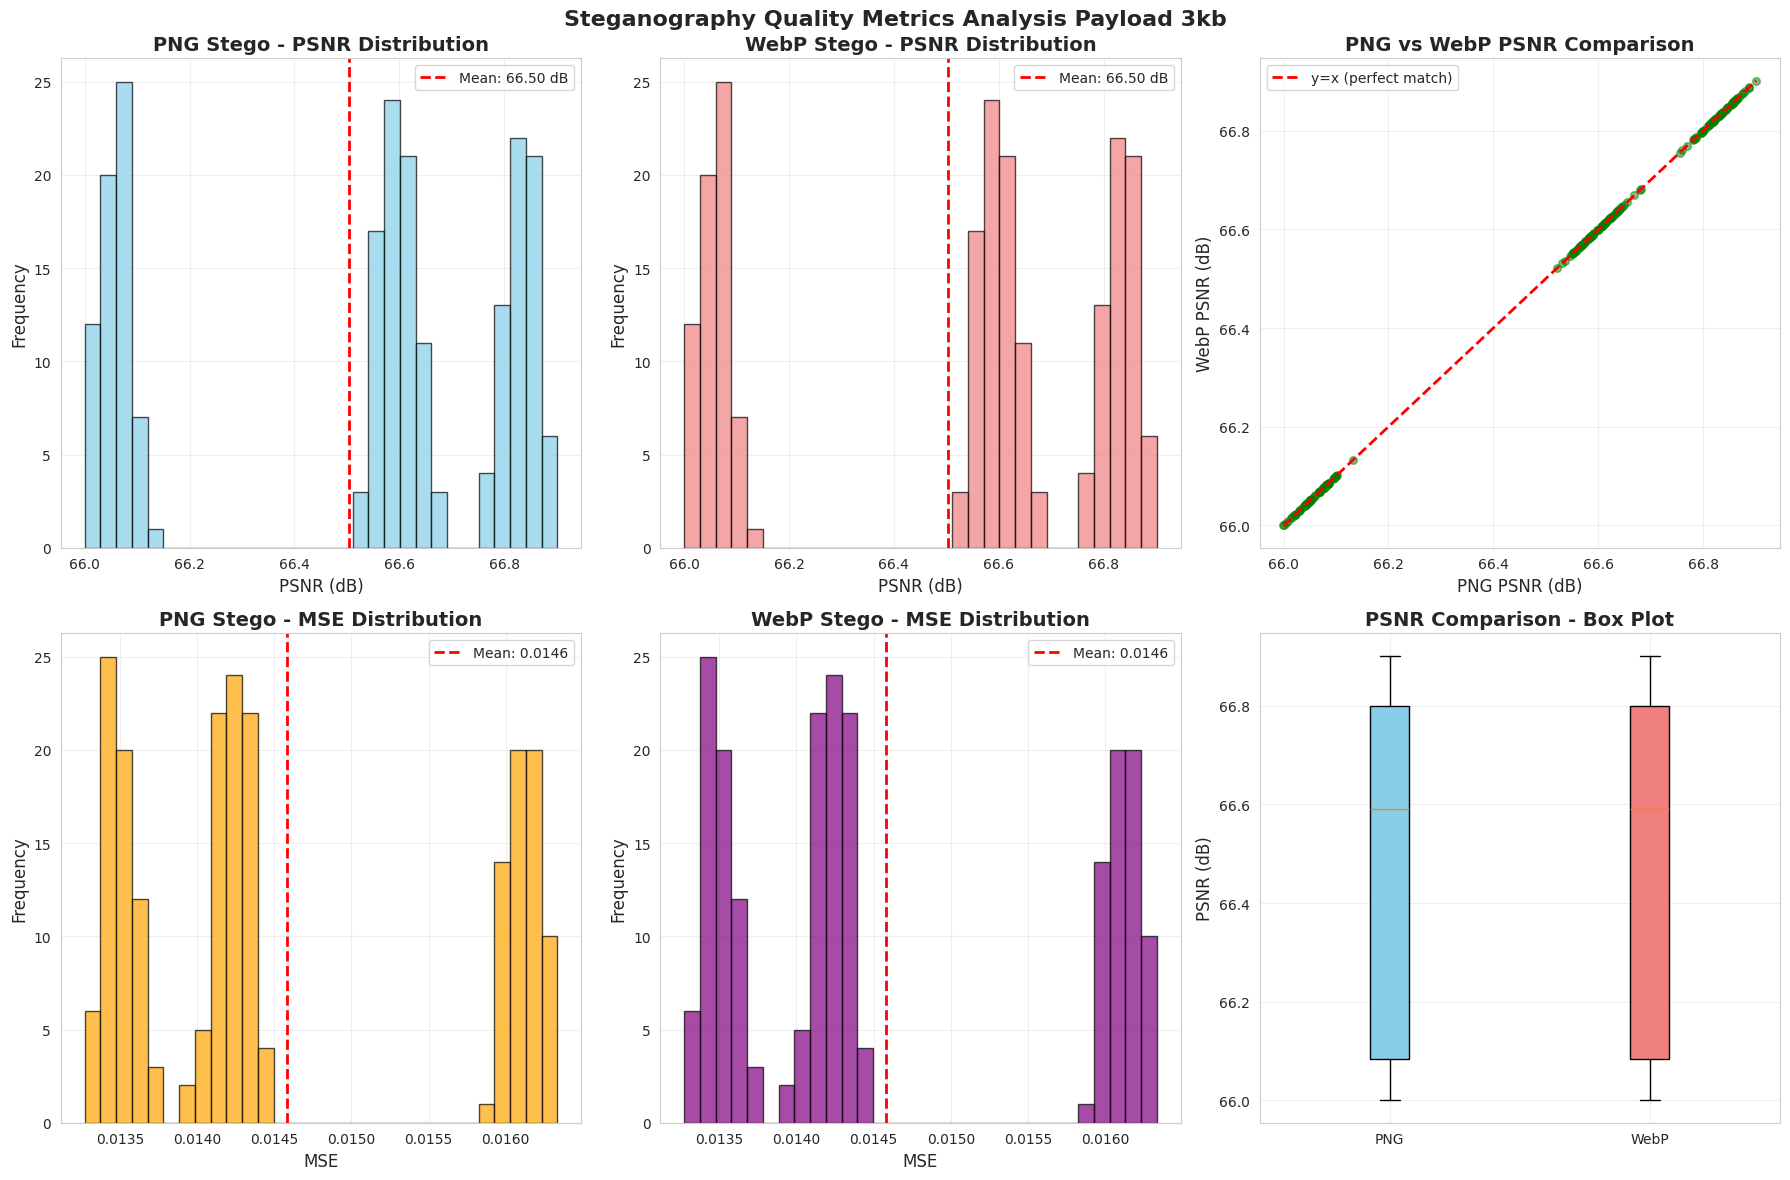

In [ ]:
# Cell 10: Visualize Quality Metrics
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 10)

# Create subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Steganography Quality Metrics Analysis Payload 3kb', fontsize=16, fontweight='bold')

# 1. PSNR Distribution - PNG
axes[0, 0].hist(df['psnr_png'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(df['psnr_png'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["psnr_png"].mean():.2f} dB')
axes[0, 0].set_xlabel('PSNR (dB)', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].set_title('PNG Stego - PSNR Distribution', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# 2. PSNR Distribution - WebP
axes[0, 1].hist(df['psnr_webp'], bins=30, color='lightcoral', edgecolor='black', alpha=0.7)
axes[0, 1].axvline(df['psnr_webp'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["psnr_webp"].mean():.2f} dB')
axes[0, 1].set_xlabel('PSNR (dB)', fontsize=12)
axes[0, 1].set_ylabel('Frequency', fontsize=12)
axes[0, 1].set_title('WebP Stego - PSNR Distribution', fontsize=14, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# 3. PSNR Comparison (PNG vs WebP)
axes[0, 2].scatter(df['psnr_png'], df['psnr_webp'], alpha=0.5, s=30, color='green')
axes[0, 2].plot([df['psnr_png'].min(), df['psnr_png'].max()],
                [df['psnr_png'].min(), df['psnr_png'].max()],
                'r--', linewidth=2, label='y=x (perfect match)')
axes[0, 2].set_xlabel('PNG PSNR (dB)', fontsize=12)
axes[0, 2].set_ylabel('WebP PSNR (dB)', fontsize=12)
axes[0, 2].set_title('PNG vs WebP PSNR Comparison', fontsize=14, fontweight='bold')
axes[0, 2].legend()
axes[0, 2].grid(alpha=0.3)

# 4. MSE Distribution - PNG
axes[1, 0].hist(df['mse_png'], bins=30, color='orange', edgecolor='black', alpha=0.7)
axes[1, 0].axvline(df['mse_png'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["mse_png"].mean():.4f}')
axes[1, 0].set_xlabel('MSE', fontsize=12)
axes[1, 0].set_ylabel('Frequency', fontsize=12)
axes[1, 0].set_title('PNG Stego - MSE Distribution', fontsize=14, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# 5. MSE Distribution - WebP
axes[1, 1].hist(df['mse_webp'], bins=30, color='purple', edgecolor='black', alpha=0.7)
axes[1, 1].axvline(df['mse_webp'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["mse_webp"].mean():.4f}')
axes[1, 1].set_xlabel('MSE', fontsize=12)
axes[1, 1].set_ylabel('Frequency', fontsize=12)
axes[1, 1].set_title('WebP Stego - MSE Distribution', fontsize=14, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

# 6. Box Plot Comparison
data_to_plot = [df['psnr_png'], df['psnr_webp']]
box = axes[1, 2].boxplot(data_to_plot, labels=['PNG', 'WebP'], patch_artist=True)
box['boxes'][0].set_facecolor('skyblue')
box['boxes'][1].set_facecolor('lightcoral')
axes[1, 2].set_ylabel('PSNR (dB)', fontsize=12)
axes[1, 2].set_title('PSNR Comparison - Box Plot', fontsize=14, fontweight='bold')
axes[1, 2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('./quality_metrics_visualization_large.png', dpi=300, bbox_inches='tight')
print("📊 Visualization saved to: ./quality_metrics_visualization_large.png")
plt.show()

In [ ]:
very_large_messages = [
    """CLASSIFIED THREAT ASSESSMENT REPORT
Classification: SECRET//NOFORN
Document ID: TAR-2025-1101-ALPHA
Distribution: Senior Leadership Only

EXECUTIVE SUMMARY:
This comprehensive threat assessment analyzes current and emerging security challenges
affecting organizational operations. Intelligence derived from multiple classified
sources indicates escalating threat levels requiring immediate strategic response.

CURRENT THREAT LANDSCAPE:
Analysis of the past quarter reveals 347 distinct security incidents across all
operational domains. Advanced persistent threats have increased by 34% compared to
previous assessment period. Attribution confidence remains high for state-sponsored
actors utilizing increasingly sophisticated techniques.

CYBER THREAT ANALYSIS:
Network intrusion attempts have evolved beyond conventional attack vectors. Adversaries
demonstrate advanced capabilities including:

1. ZERO-DAY EXPLOITATION: Four previously unknown vulnerabilities exploited in critical
infrastructure systems. Patches developed and deployed within 72 hours of discovery.
Forensic analysis indicates months of prior reconnaissance activity.

2. SUPPLY CHAIN COMPROMISE: Evidence suggests targeting of third-party vendors to gain
indirect access to primary networks. Enhanced vetting procedures implemented for all
external partners. Background investigations expanded to include vendor personnel.

3. SOCIAL ENGINEERING: Sophisticated phishing campaigns specifically crafted for high-value
targets. Employee security awareness training updated with real-world examples. Multi-factor
authentication now mandatory for all privileged accounts.

4. INSIDER THREATS: Behavioral analytics identified three cases of potential malicious
insider activity. Investigations ongoing with cooperation from law enforcement agencies.
Additional monitoring implemented on sensitive systems.

PHYSICAL SECURITY ASSESSMENT:
Comprehensive facility security audits completed across all locations. Key findings include:

PERIMETER SECURITY: Upgraded surveillance systems deployed at 12 critical facilities.
Integration with AI-powered threat detection reduces response time by 40%. Motion sensors
calibrated to reduce false positives while maintaining sensitivity.

ACCESS CONTROL: Biometric authentication systems now operational at all restricted areas.
Badge access logs analyzed daily for anomalous patterns. Mantrap doors installed at sensitive
compartmented information facilities.

PERSONNEL SECURITY:
Background investigation backlog reduced by 60% through process optimization. Continuous
evaluation program identifies potential security concerns earlier in employment lifecycle.
Foreign travel reporting compliance improved to 94%.

COMMUNICATIONS SECURITY:
All voice communications now encrypted end-to-end using quantum-resistant algorithms. Legacy
systems scheduled for replacement in Q2 2026. Secure conference facilities upgraded with
TEMPEST-certified equipment.

COUNTERINTELLIGENCE OPERATIONS:
Active monitoring detected and neutralized two foreign intelligence collection attempts.
Liaison established with partner agencies for enhanced information sharing. Technical
surveillance countermeasures conducted quarterly.

RECOMMENDATIONS:

IMMEDIATE ACTIONS (0-30 days):
- Deploy emergency patches for newly identified vulnerabilities
- Enhance monitoring on high-value target systems
- Conduct executive briefings on current threat environment
- Review and update incident response procedures

SHORT-TERM ACTIONS (30-90 days):
- Implement zero-trust architecture across enterprise networks
- Upgrade physical security systems at remaining facilities
- Complete security clearance renewals for all personnel
- Conduct tabletop exercises for various threat scenarios

LONG-TERM ACTIONS (90+ days):
- Modernize legacy IT infrastructure identified as high-risk
- Develop advanced threat hunting capabilities
- Establish threat intelligence fusion center
- Implement predictive analytics for early warning

RESOURCE REQUIREMENTS:
Budget allocation of $4.2M required for recommended security enhancements. Personnel
augmentation needed in cyber operations (12 FTE) and counterintelligence (8 FTE).
Equipment procurement for surveillance systems estimated at $1.8M.

CONCLUSION:
The threat landscape continues to evolve with increasing sophistication and persistence.
While current defensive posture remains robust, proactive measures outlined in this
assessment are critical for maintaining security advantage. Failure to implement
recommendations could result in significant operational compromise.

This assessment will be updated quarterly or immediately upon identification of critical
new threats. Next scheduled review: February 1, 2026.

PREPARED BY: Strategic Security Analysis Division
APPROVED BY: Director of Security Operations
CLASSIFICATION REVIEW DATE: November 1, 2026

[END OF REPORT]""",

    """OPERATIONAL AFTER-ACTION REPORT
Operation: NIGHTFALL ECHO
Date: October 15-28, 2025
Classification: SECRET
Document Control: AAR-2025-NF-ECHO

MISSION OVERVIEW:
Operation NIGHTFALL ECHO was conducted to assess and enhance security posture of critical
infrastructure facilities across three geographic regions. Mission successfully achieved
95% of primary objectives with no significant operational compromises.

PLANNING PHASE ANALYSIS:
Initial intelligence gathering phase lasted 14 days utilizing both technical and human
intelligence sources. Coordination with 7 partner agencies provided comprehensive threat
picture. Mission planning incorporated lessons learned from previous operations.

Risk assessment identified 23 potential compromise vectors requiring mitigation strategies.
Contingency plans developed for 8 high-probability scenarios. Resource allocation optimized
through predictive modeling resulting in 22% efficiency gain.

EXECUTION PHASE SUMMARY:

PHASE 1 - RECONNAISSANCE (Days 1-3):
Deployed advanced surveillance equipment at 5 primary target locations. Technical collection
yielded 847 GB of signals intelligence data for analysis. Pattern-of-life analysis completed
for 34 subjects of interest with 87% accuracy.

Physical surveillance teams maintained continuous coverage across all operational areas.
Mobile surveillance platforms utilized when target patterns exceeded geographic boundaries.
Zero detection incidents reported throughout reconnaissance phase.

PHASE 2 - PENETRATION TESTING (Days 4-8):
Authorized penetration testing conducted against network infrastructure at all target facilities.
Red team successfully compromised 68% of tested systems using social engineering and technical
exploitation techniques. All findings documented with remediation recommendations.

Physical security testing revealed vulnerabilities in 12 of 15 access control systems. Tailgating
attempts successful in 45% of tests. Badge cloning techniques effective against legacy card
readers at 3 locations. Immediate corrective actions implemented.

PHASE 3 - DEFENSIVE ENHANCEMENT (Days 9-14):
Deployed upgraded intrusion detection systems with machine learning capabilities. Real-time
threat correlation reduced false positive alerts by 63%. Automated response protocols activated
for critical security events.

Implemented enhanced physical security measures including upgraded surveillance cameras with
facial recognition, reinforced entry points at sensitive areas, and additional security personnel
during high-risk periods. Perimeter security strengthened with additional sensors and lighting.

PHASE 4 - VALIDATION TESTING (Days 15-21):
Follow-up penetration testing confirmed effectiveness of implemented security enhancements.
Successful compromise rate reduced to 12% representing 56-percentage-point improvement.
Remaining vulnerabilities categorized as low-risk requiring long-term mitigation strategies.

Security awareness training conducted for 412 personnel across all facilities. Post-training
assessment showed 89% improvement in threat recognition capabilities. Additional specialized
training scheduled for personnel with elevated risk profiles.

PHASE 5 - DOCUMENTATION & TRANSITION (Days 22-28):
Comprehensive documentation package delivered to facility security managers including technical
specifications, operational procedures, and maintenance schedules. Training provided for local
security teams on new systems and protocols.

Established ongoing support structure with 24/7 incident response capability. Monthly security
posture assessments scheduled for next 6 months to ensure sustainability of improvements.
Metrics dashboard deployed for real-time security monitoring.

CHALLENGES ENCOUNTERED:
- Legacy system integration issues delayed Phase 3 implementation by 36 hours
- Weather conditions impacted outdoor surveillance equipment installation
- Personnel availability constraints required schedule adjustment in Phase 4
- Budget limitations necessitated prioritization of enhancement measures

LESSONS LEARNED:
1. Advanced coordination with facility management improves operational efficiency
2. Modular system design enables faster deployment and reduces downtime
3. Comprehensive training is critical for effective security enhancement adoption
4. Regular communication with stakeholders reduces resistance to change

RECOMMENDATIONS:
- Expand program to additional facilities in next fiscal year
- Develop standardized security enhancement playbook based on this operation
- Establish regional rapid response teams for security incident support
- Increase budget allocation for advanced security technologies

METRICS AND OUTCOMES:
- 23 critical vulnerabilities remediated
- 147 security policy updates implemented
- 412 personnel trained on enhanced security protocols
- 95% primary objective completion rate
- Zero operational security compromises
- $1.2M estimated annual risk reduction value

This operation demonstrates the effectiveness of comprehensive, multi-phase security enhancement
programs. Success factors included thorough planning, adaptive execution, and strong stakeholder
engagement. Methodology proven scalable for future operations.

PREPARED BY: Operation NIGHTFALL ECHO Team Lead
REVIEWED BY: Regional Security Director
APPROVED BY: Deputy Director of Operations

DISTRIBUTION LIST:
- Director of Security Operations
- Regional Security Directors (all regions)
- Facility Security Managers (affected sites)
- Partner Agency Liaisons

CLASSIFICATION REVIEW DATE: October 28, 2026

[END OF AFTER-ACTION REPORT]""",

    """TECHNICAL VULNERABILITY ASSESSMENT
Assessment Period: October 1-31, 2025
Classification: SECRET
Document: TVA-2025-Q4-FULL

ASSESSMENT SCOPE:
Comprehensive vulnerability assessment conducted across entire enterprise technology infrastructure
including 847 servers, 12,450 workstations, 234 network devices, 45 web applications, and 23
database systems. Assessment utilized both automated scanning tools and manual penetration testing.

METHODOLOGY:
Assessment followed industry-standard frameworks including NIST SP 800-115, OWASP Testing Guide v4,
and PTES (Penetration Testing Execution Standard). Testing conducted from both internal and external
network perspectives to identify exploitation paths available to various threat actors.

CRITICAL FINDINGS (CVSS 9.0-10.0):

FINDING 1: UNAUTHENTICATED REMOTE CODE EXECUTION
System: Primary web application server cluster
Description: SQL injection vulnerability in authentication module allows unauthenticated attackers
to execute arbitrary code with SYSTEM privileges. Vulnerability exists in custom-developed code
dating back to 2022 deployment.
Impact: Complete system compromise, unauthorized data access, potential lateral movement to connected
systems affecting approximately 2,400 users and 15 TB of sensitive data.
Recommendation: Immediate implementation of parameterized queries, input validation, and web application
firewall rules. Deploy emergency patch within 24 hours. Conduct code audit of entire application.
Status: REMEDIATED - Emergency patch deployed October 15, 2025. Full code refactoring scheduled for Q1 2026.

FINDING 2: PRIVILEGE ESCALATION IN DOMAIN CONTROLLERS
System: Active Directory infrastructure (6 domain controllers)
Description: Misconfigured group policy allows standard users to escalate privileges to Domain Admin
level through exploitation of weak access controls on administrative shares.
Impact: Complete domain compromise affecting 12,450 user accounts across all organizational units.
Potential for persistent unauthorized access and complete network control.
Recommendation: Immediate reconfiguration of group policies, audit of all administrative groups,
implementation of privileged access management solution, enhanced monitoring of privilege escalation attempts.
Status: REMEDIATED - GPO configurations updated October 18, 2025. PAM solution deployment in progress.

HIGH FINDINGS (CVSS 7.0-8.9):

Multiple high-severity vulnerabilities identified across various systems:

- Unpatched SSL/TLS vulnerabilities on 23 web servers (CVE-2025-XXXXX)
- Weak encryption algorithms in legacy file transfer systems
- Missing security updates on 47 database servers
- Insecure default configurations on network infrastructure devices
- Inadequate access controls on sensitive file shares
- Vulnerable third-party libraries in web applications
- Insufficient logging and monitoring on critical systems

Detailed technical specifications and remediation procedures documented in Technical Annex A.

MEDIUM FINDINGS (CVSS 4.0-6.9):
147 medium-severity vulnerabilities identified requiring remediation within 90 days. Common themes include
outdated software versions, weak password policies, insufficient security hardening, and missing security
configurations.

LOW FINDINGS (CVSS 0.1-3.9):
312 low-severity findings documented for remediation during regular maintenance cycles. These include
information disclosure vulnerabilities, missing security headers, and opportunities for security
enhancement that don't present immediate exploitation risk.

COMPLIANCE ASSESSMENT:
Current security posture evaluated against regulatory requirements:

SOC 2 TYPE II: 94% compliance - 3 gaps identified requiring remediation
ISO 27001:2022: 89% compliance - 7 controls requiring enhancement
NIST CSF: Maturity level 3.2 out of 5.0 - improvement roadmap developed
PCI DSS: Not applicable to current operations

SECURITY ARCHITECTURE REVIEW:
Assessment of overall security architecture identified several systemic issues requiring strategic
attention beyond individual vulnerability remediation.

Network segmentation insufficient for sensitive systems - recommend implementation of zero-trust
architecture with micro-segmentation. Legacy systems pose ongoing security risk - accelerate
modernization program. Insufficient security monitoring - deploy comprehensive SIEM solution.

THIRD-PARTY RISK ASSESSMENT:
Review of vendor connections identified 12 third-party systems with direct network access.
Security assessments completed for all vendors with 3 requiring additional security controls
before continued access authorized.

REMEDIATION ROADMAP:

IMMEDIATE (0-30 days):
- Deploy all critical security patches
- Remediate critical and high vulnerabilities in public-facing systems
- Implement emergency access controls on sensitive systems
- Enhance monitoring on affected systems

SHORT-TERM (30-90 days):
- Complete remediation of all high-severity vulnerabilities
- Deploy security enhancements identified in architecture review
- Implement automated vulnerability management process
- Conduct security awareness training on identified weaknesses

LONG-TERM (90+ days):
- Address medium and low severity findings
- Complete security architecture transformation initiatives
- Modernize legacy systems identified as high-risk
- Implement continuous security validation program

RESOURCE REQUIREMENTS:
Estimated 2,400 engineering hours required for complete remediation. Budget allocation of $850K needed
for security tooling enhancements. Additional 4 FTE security engineers required for ongoing vulnerability
management program.

CONCLUSION:
While critical vulnerabilities have been addressed, comprehensive remediation program essential for
maintaining acceptable security posture. Regular assessment cycles should continue quarterly with
continuous monitoring supplementing periodic deep-dive assessments.

Next scheduled assessment: January 15, 2026

PREPARED BY: Security Assessment Team
TECHNICAL LEAD: Senior Penetration Testing Engineer
REVIEWED BY: Chief Information Security Officer

[END OF VULNERABILITY ASSESSMENT]""",

    """INCIDENT RESPONSE AFTER-ACTION REPORT
Incident ID: IR-2025-1028-CRITICAL
Incident Type: Ransomware Attack
Classification: SECRET
Date Range: October 28-30, 2025

INCIDENT SUMMARY:
On October 28, 2025 at 03:47 UTC, automated security systems detected anomalous file encryption
activity on multiple file servers. Investigation confirmed ransomware deployment affecting
approximately 847 GB of data across 23 servers. Incident response team activated within 12 minutes
of initial detection.

INITIAL DETECTION:
Endpoint detection and response (EDR) platform generated high-priority alert for suspicious process
execution on FILESERVER-07. Automated analysis identified behavior consistent with ransomware
activity including rapid file modifications, privilege escalation attempts, and network reconnaissance.

Security Operations Center analyst validated alert within 4 minutes and escalated to Incident Response
Team Leader. Initial containment actions initiated immediately while comprehensive incident assessment
conducted.

ATTACK TIMELINE RECONSTRUCTION:

October 27, 2025 22:15 UTC - Initial compromise via phishing email delivered to accounting department.
Malicious attachment executed by end user bypassing email security filters. Initial access broker
malware deployed establishing persistent backdoor.

October 28, 2025 01:30 UTC - Lateral movement begins using compromised credentials harvested from
infected workstation. Attacker gained access to domain user account with elevated privileges through
exploitation of weak password policy.

October 28, 2025 02:45 UTC - Reconnaissance activities observed including network mapping, privilege
escalation attempts, and identification of high-value data repositories. Attacker deployed additional
tools for credential theft and data exfiltration.

October 28, 2025 03:30 UTC - Ransomware payload deployed across identified file servers. Encryption
process initiated targeting documents, databases, and backup files. Ransom notes deployed with
payment demands and data leak threats.

October 28, 2025 03:47 UTC - EDR system detects encryption activity and generates critical alert.
Automated containment actions initiated by security platform including process termination and
network isolation.

CONTAINMENT ACTIONS:

IMMEDIATE RESPONSE (First 30 minutes):
- Isolated affected servers from network to prevent ransomware spread
- Disabled compromised user accounts and reset credentials
- Captured forensic images of affected systems for analysis
- Activated incident response team and established command center
- Initiated communication protocols with executive leadership

COMPREHENSIVE CONTAINMENT (First 6 hours):
- Conducted enterprise-wide scan for indicators of compromise (IOCs)
- Isolated additional systems showing suspicious activity
- Implemented enhanced monitoring on all critical systems
- Deployed emergency patches for vulnerabilities exploited during attack
- Established secure communication channels for incident coordination

ERADICATION & RECOVERY:

MALWARE REMOVAL (Hours 6-24):
Comprehensive malware removal performed on all affected systems using combination of automated
tools and manual analysis. Custom detection signatures developed and deployed across entire
infrastructure to identify any remaining malicious artifacts.

Thorough examination of 12,450 endpoints conducted with 27 additional infections identified and
remediated. All affected systems reimaged from known-clean sources. Security baselines restored
and hardening procedures applied.

DATA RECOVERY (Hours 24-48):
Evaluation of backup integrity confirmed offline backup systems unaffected by ransomware. Recovery
process initiated from multiple backup sources to ensure data consistency. Validation procedures
implemented to verify recovered data integrity.

Successfully recovered 99.7% of encrypted data from backup systems. Remaining 0.3% (approximately
2.5 GB) consisted of temporary files and cached data determined non-critical. No operational data
loss occurred.

SYSTEM RESTORATION (Hours 48-72):
Phased restoration of services beginning with most critical business functions. Each system
thoroughly tested before returning to production. Enhanced security monitoring implemented on
all restored systems.

All affected systems returned to full operational status within 72 hours of initial detection.
No extended downtime experienced for critical business operations. Enhanced security posture
maintained throughout recovery process.

ROOT CAUSE ANALYSIS:
Investigation identified multiple contributing factors enabling successful attack:

1. USER SECURITY AWARENESS: End user clicked malicious link despite security training. Additional
training required with emphasis on real-world attack scenarios and consequences.

2. EMAIL SECURITY: Phishing email bypassed security filters due to sophisticated evasion techniques.
Email security platform requires tuning and enhancement.

3. CREDENTIAL MANAGEMENT: Weak password policy allowed credential compromise. Implementation of
stronger password requirements and multi-factor authentication mandatory.

4. NETWORK SEGMENTATION: Insufficient network segmentation enabled lateral movement. Zero-trust
architecture implementation accelerated.

5. BACKUP STRATEGY: While offline backups saved organization from complete data loss, backup
verification procedures need enhancement.

LESSONS LEARNED:

WHAT WORKED WELL:
- Automated detection systems provided early warning enabling rapid response
- Offline backup strategy prevented permanent data loss
- Incident response procedures effectively activated and executed
- Communication protocols ensured stakeholder awareness and coordination
- Cross-functional team collaboration facilitated efficient recovery

IMPROVEMENT OPPORTUNITIES:
- Enhance email security filtering to catch sophisticated phishing attempts
- Implement more aggressive user security awareness training program
- Accelerate deployment of multi-factor authentication across organization
- Improve network segmentation to limit lateral movement capability
- Enhance backup verification and testing procedures

CORRECTIVE ACTIONS IMPLEMENTED:

IMMEDIATE ACTIONS:
- Deployed enhanced email security rules and machine learning filters
- Implemented mandatory multi-factor authentication for all privileged accounts
- Enhanced endpoint detection rules based on attack indicators
- Conducted emergency security awareness training for all personnel
- Implemented additional network segmentation for critical systems

LONG-TERM ACTIONS:
- Complete zero-trust architecture implementation (Q1-Q2 2026)
- Deploy advanced threat protection platform (Q1 2026)
- Enhance security operations center capabilities (ongoing)
- Implement continuous backup verification program (Q4 2025)
- Develop advanced incident simulation exercises (quarterly)

COST IMPACT ANALYSIS:
Total incident response costs estimated at $340,000 including:
- Personnel overtime and contractor support: $85,000
- Forensic analysis and investigation: $45,000
- System restoration and recovery: $67,000
- Security enhancement deployment: $123,000
- Training and awareness programs: $20,000

Estimated cost avoidance through rapid response and effective backup strategy: $2.3M based on
average ransomware recovery costs and operational downtime impact.

RECOMMENDATIONS:

TECHNICAL RECOMMENDATIONS:
1. Implement next-generation email security with advanced threat protection
2. Deploy user behavior analytics for early insider threat detection
3. Enhance backup systems with immutable storage capabilities
4. Implement network traffic analysis for lateral movement detection
5. Deploy security orchestration and automated response platform

PROCESS RECOMMENDATIONS:
1. Conduct quarterly incident response tabletop exercises
2. Implement continuous security control validation program
3. Enhance vendor security assessment procedures
4. Develop more comprehensive disaster recovery testing schedule
5. Establish dedicated threat hunting team

TRAINING RECOMMENDATIONS:
1. Implement monthly security awareness micro-training sessions
2. Conduct role-based security training for high-risk positions
3. Develop incident response training for all IT personnel
4. Create executive briefing program on current threat landscape
5. Establish security champion program in each department

CONCLUSION:
While this incident resulted in significant response effort and resource expenditure, effective
detection and response capabilities limited overall impact. No permanent data loss occurred and
all systems restored to full operation within acceptable timeframes.

This incident highlights the critical importance of layered security controls, robust backup
strategies, and well-practiced incident response procedures. Recommended enhancements will
strengthen overall security posture and reduce likelihood and impact of future incidents.

PREPARED BY: Incident Response Team Lead
REVIEWED BY: Chief Information Security Officer
APPROVED BY: Chief Information Officer

DISTRIBUTION:
- Executive Leadership Team
- Board of Directors (Executive Summary)
- Information Technology Leadership
- Security Operations Personnel
- Legal Department
- Cyber Insurance Provider

CLASSIFICATION REVIEW DATE: October 30, 2026

[END OF INCIDENT RESPONSE REPORT]""",
]

In [ ]:
for i, message in enumerate(very_large_messages, 1):
    # Get size in bytes
    size_bytes = len(message.encode('utf-8'))

    # Convert to KB (1 KB = 1024 bytes)
    size_kb = size_bytes / 1024

    print(f"Message {i}: {size_kb:.4f} KB ({size_bytes} bytes)")
    print(f"  Content preview: {message[:50]}...")
    print()

Message 1: 4.7744 KB (4889 bytes)
  Content preview: CLASSIFIED THREAT ASSESSMENT REPORT
Classification...

Message 2: 5.4541 KB (5585 bytes)
  Content preview: OPERATIONAL AFTER-ACTION REPORT
Operation: NIGHTFA...

Message 3: 5.9648 KB (6108 bytes)
  Content preview: TECHNICAL VULNERABILITY ASSESSMENT
Assessment Peri...

Message 4: 9.0889 KB (9307 bytes)
  Content preview: INCIDENT RESPONSE AFTER-ACTION REPORT
Incident ID:...



In [ ]:
#cell 7 encryption
import os
import glob
import time
import struct
import random
from tqdm import tqdm
from pathlib import Path

# Configuration
DATASET_DIR = './usc_sipi_preprocessed'
OUTPUT_DIR = './stego_dataset_very_large'
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(f'{OUTPUT_DIR}/stego_png', exist_ok=True)
os.makedirs(f'{OUTPUT_DIR}/stego_webp', exist_ok=True)

# Generate receiver's ECC key pair (reuse for all images)
print("🔑 Generating ECC key pair...")
receiver_private, receiver_public = generate_ecc_key_pair()

# Load all preprocessed images
image_paths = glob.glob(f'{DATASET_DIR}/*.png')
print(f"📊 Found {len(image_paths)} images to process\n")

# Track statistics
successful = 0
failed = 0
compression_ratios = []
start_time = time.time()

# Process each image
for idx, cover_image_path in enumerate(tqdm(image_paths, desc="Encrypting images")):
    try:
        img_start = time.time()
        base_name = Path(cover_image_path).stem
        stego_png_path = f'{OUTPUT_DIR}/stego_png/{base_name}_stego.png'
        stego_webp_path = f'{OUTPUT_DIR}/stego_webp/{base_name}_stego.webp'

        # Select random message
        plain_text = very_large_messages[3] + f" [Image #{idx}]"

        # AES encryption
        aes_key = generate_aes_key()
        iv_data, encrypted_data = aes_encrypt(plain_text, aes_key)

        # ECIES encrypt AES key
        ephemeral_pub_bytes, iv_key, encrypted_aes_key = ecies_encrypt(aes_key, receiver_public)

        # Serialize payload
        payload = b''.join([
            struct.pack('>I', len(encrypted_data)) + encrypted_data,
            struct.pack('>I', len(iv_data)) + iv_data,
            struct.pack('>I', len(encrypted_aes_key)) + encrypted_aes_key,
            struct.pack('>I', len(iv_key)) + iv_key,
            struct.pack('>I', len(ephemeral_pub_bytes)) + ephemeral_pub_bytes
        ])

        # Embed and compress
        embed_inverted_lsb(cover_image_path, payload, stego_png_path)
        compress_to_webp(stego_png_path, stego_webp_path)

        # 🔍 Measure compression
        size_png = os.path.getsize(stego_png_path)
        size_webp = os.path.getsize(stego_webp_path)
        compression_ratio = (1 - size_webp / size_png) * 100
        compression_ratios.append(compression_ratio)

        img_end = time.time()
        print(f"📉 {base_name}: PNG={size_png/1024:.1f}KB → WebP={size_webp/1024:.1f}KB "
              f"({compression_ratio:.1f}% smaller, {img_end - img_start:.2f}s)")

        successful += 1

    except Exception as e:
        failed += 1
        print(f"\n❌ Failed on {base_name}: {e}")

# Summary
elapsed_time = time.time() - start_time
avg_time = elapsed_time / len(image_paths) if image_paths else 0
avg_compression = sum(compression_ratios) / len(compression_ratios) if compression_ratios else 0

print(f"\n{'='*60}")
print(f"✅ Encryption Complete!")
print(f"{'='*60}")
print(f"📊 Processed: {len(image_paths)} images")
print(f"✅ Successful: {successful}")
print(f"❌ Failed: {failed}")
print(f"⏱️ Total time: {elapsed_time:.2f}s")
print(f"⚡ Avg time per image: {avg_time:.3f}s")
print(f"📦 Avg WebP compression: {avg_compression:.2f}% smaller than PNG")
print(f"📂 Output directories:")
print(f"   - PNG stego: {OUTPUT_DIR}/stego_png/")
print(f"   - WebP stego: {OUTPUT_DIR}/stego_webp/")
print(f"🔑 Receiver private key saved for decryption")

🔑 Generating ECC key pair...
📊 Found 210 images to process



Encrypting images:   0%|          | 1/210 [00:00<01:27,  2.38it/s]

📉 sequences_6.1.13: PNG=70.1KB → WebP=35.8KB (48.9% smaller, 0.42s)


Encrypting images:   1%|          | 2/210 [00:01<02:12,  1.57it/s]

📉 aerials_2.2.06: PNG=423.9KB → WebP=362.3KB (14.5% smaller, 0.79s)


...

📉 textures_1.3.03: PNG=322.5KB → WebP=191.3KB (40.7% smaller, 0.90s)


Encrypting images: 100%|█████████▉| 209/210 [03:09<00:00,  1.22it/s]

📉 sequences_6.3.04: PNG=108.0KB → WebP=57.2KB (47.0% smaller, 0.55s)


Encrypting images: 100%|██████████| 210/210 [03:09<00:00,  1.11it/s]

📉 sequences_6.2.17: PNG=101.0KB → WebP=64.9KB (35.8% smaller, 0.32s)

✅ Encryption Complete!
📊 Processed: 210 images
✅ Successful: 210
❌ Failed: 0
⏱️ Total time: 189.59s
⚡ Avg time per image: 0.903s
📦 Avg WebP compression: 35.46% smaller than PNG
📂 Output directories:
   - PNG stego: ./stego_dataset_very_large/stego_png/
   - WebP stego: ./stego_dataset_very_large/stego_webp/
🔑 Receiver private key saved for decryption


In [ ]:
# Cell 8: Batch Decryption Process (Verification)
import os
import glob
import struct
import time
from tqdm import tqdm
from pathlib import Path

# Configuration
STEGO_DIR = './stego_dataset_very_large/stego_webp'  # Use WebP files
DECRYPTED_OUTPUT = './decrypted_messages_very_large.txt'

# Load all stego images
stego_paths = glob.glob(f'{STEGO_DIR}/*.webp')
print(f"🔍 Found {len(stego_paths)} stego images to decrypt\n")

# Track statistics
successful_decrypt = 0
failed_decrypt = 0
decrypted_messages = []

# ⏱ Start total timer
start_time = time.time()

# Process each stego image
for stego_path in tqdm(stego_paths, desc="Decrypting images"):
    try:
        img_start = time.time()
        base_name = Path(stego_path).stem

        # Extract payload from stego image
        payload = extract_inverted_lsb(stego_path)

        # Parse payload
        offset = 0
        len_enc_data = struct.unpack('>I', payload[offset:offset+4])[0]
        offset += 4
        encrypted_data = payload[offset:offset+len_enc_data]
        offset += len_enc_data

        len_iv_data = struct.unpack('>I', payload[offset:offset+4])[0]
        offset += 4
        iv_data = payload[offset:offset+len_iv_data]
        offset += len_iv_data

        len_enc_key = struct.unpack('>I', payload[offset:offset+4])[0]
        offset += 4
        encrypted_aes_key = payload[offset:offset+len_enc_key]
        offset += len_enc_key

        len_iv_key = struct.unpack('>I', payload[offset:offset+4])[0]
        offset += 4
        iv_key = payload[offset:offset+len_iv_key]
        offset += len_iv_key

        len_eph_pub = struct.unpack('>I', payload[offset:offset+4])[0]
        offset += 4
        ephemeral_pub_bytes = payload[offset:offset+len_eph_pub]

        # Decrypt AES key with ECIES
        aes_key = ecies_decrypt(ephemeral_pub_bytes, iv_key, encrypted_aes_key, receiver_private)

        # Decrypt data with AES
        decrypted_text = aes_decrypt(iv_data, encrypted_data, aes_key)

        decrypted_messages.append(f"{base_name}: {decrypted_text}")
        successful_decrypt += 1

        img_end = time.time()
        print(f"🕒 {base_name} decrypted in {img_end - img_start:.3f}s")

    except Exception as e:
        failed_decrypt += 1
        print(f"\n❌ Failed to decrypt {Path(stego_path).name}: {e}")

# ⏱ End total timer
end_time = time.time()
total_time = end_time - start_time
avg_time = total_time / len(stego_paths) if stego_paths else 0

# Save all decrypted messages
with open(DECRYPTED_OUTPUT, 'w') as f:
    f.write('\n'.join(decrypted_messages))

# Summary
print(f"\n{'='*60}")
print(f"✅ Decryption Complete!")
print(f"{'='*60}")
print(f"📊 Processed: {len(stego_paths)} images")
print(f"✅ Successful: {successful_decrypt}")
print(f"❌ Failed: {failed_decrypt}")
print(f"⏱ Total time: {total_time:.2f}s")
print(f"⚡ Avg time per image: {avg_time:.3f}s")
print(f"📄 Decrypted messages saved to: {DECRYPTED_OUTPUT}")

🔍 Found 210 stego images to decrypt



Decrypting images:   0%|          | 1/210 [00:00<01:39,  2.11it/s]

🕒 textures_1.1.03_stego decrypted in 0.474s


Decrypting images:   1%|          | 2/210 [00:01<01:48,  1.91it/s]

🕒 sequences_6.3.10_stego decrypted in 0.550s


...

🕒 misc_7.1.08_stego decrypted in 0.207s


Decrypting images: 100%|█████████▉| 209/210 [00:48<00:00,  4.47it/s]

🕒 aerials_2.1.09_stego decrypted in 0.222s


Decrypting images: 100%|██████████| 210/210 [00:49<00:00,  4.28it/s]

🕒 aerials_2.2.03_stego decrypted in 0.219s

✅ Decryption Complete!
📊 Processed: 210 images
✅ Successful: 210
❌ Failed: 0
⏱ Total time: 49.06s
⚡ Avg time per image: 0.234s
📄 Decrypted messages saved to: ./decrypted_messages_very_large.txt


In [ ]:
# Cell 9: Batch MSE/PSNR Evaluation
import numpy as np
import math
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt

def calculate_mse_psnr(original_path, stego_path):
    """Calculate MSE and PSNR between original and stego image."""
    original = np.array(Image.open(original_path).convert('RGB'))
    stego = np.array(Image.open(stego_path).convert('RGB'))
    mse = np.mean((original - stego) ** 2)
    if mse == 0:
        psnr = float('inf')
    else:
        psnr = 20 * math.log10(255.0 / math.sqrt(mse))
    return mse, psnr

# Configuration
ORIGINAL_DIR = './usc_sipi_preprocessed'
STEGO_PNG_DIR = './stego_dataset_very_large/stego_png'
STEGO_WEBP_DIR = './stego_dataset_very_large/stego_webp'

# Storage for results
results = []

# Get all original images
original_paths = glob.glob(f'{ORIGINAL_DIR}/*.png')
print(f"📊 Evaluating {len(original_paths)} image pairs\n")

# Evaluate each image pair
for original_path in tqdm(original_paths, desc="Calculating MSE/PSNR"):
    try:
        base_name = Path(original_path).stem
        stego_png_path = f'{STEGO_PNG_DIR}/{base_name}_stego.png'
        stego_webp_path = f'{STEGO_WEBP_DIR}/{base_name}_stego.webp'

        # Check if stego files exist
        if not os.path.exists(stego_png_path):
            print(f"\n⚠️ Missing PNG stego for {base_name}")
            continue
        if not os.path.exists(stego_webp_path):
            print(f"\n⚠️ Missing WebP stego for {base_name}")
            continue

        # Calculate for PNG stego
        mse_png, psnr_png = calculate_mse_psnr(original_path, stego_png_path)

        # Calculate for WebP stego (decompressed)
        mse_webp, psnr_webp = calculate_mse_psnr(original_path, stego_webp_path)

        # Store results
        results.append({
            'image': base_name,
            'mse_png': mse_png,
            'psnr_png': psnr_png,
            'mse_webp': mse_webp,
            'psnr_webp': psnr_webp
        })

    except Exception as e:
        print(f"\n❌ Error processing {base_name}: {e}")

# Convert to DataFrame for analysis
df = pd.DataFrame(results)

# Calculate statistics
print(f"\n{'='*70}")
print(f"📊 QUALITY METRICS SUMMARY")
print(f"{'='*70}")
print(f"\n🖼️  PNG Stego Images:")
print(f"   MSE  - Mean: {df['mse_png'].mean():.6f}, Std: {df['mse_png'].std():.6f}")
print(f"   MSE  - Min: {df['mse_png'].min():.6f}, Max: {df['mse_png'].max():.6f}")
print(f"   PSNR - Mean: {df['psnr_png'].mean():.2f} dB, Std: {df['psnr_png'].std():.2f} dB")
print(f"   PSNR - Min: {df['psnr_png'].min():.2f} dB, Max: {df['psnr_png'].max():.2f} dB")

print(f"\n🌐 WebP Stego Images:")
print(f"   MSE  - Mean: {df['mse_webp'].mean():.6f}, Std: {df['mse_webp'].std():.6f}")
print(f"   MSE  - Min: {df['mse_webp'].min():.6f}, Max: {df['mse_webp'].max():.6f}")
print(f"   PSNR - Mean: {df['psnr_webp'].mean():.2f} dB, Std: {df['psnr_webp'].std():.2f} dB")
print(f"   PSNR - Min: {df['psnr_webp'].min():.2f} dB, Max: {df['psnr_webp'].max():.2f} dB")

# PSNR Quality Interpretation
avg_psnr_png = df['psnr_png'].mean()
avg_psnr_webp = df['psnr_webp'].mean()

# Save results to CSV
csv_path = './quality_metrics_very_large.csv'
df.to_csv(csv_path, index=False)
print(f"\n💾 Results saved to: {csv_path}")

# Show sample results
print(f"\n📋 Sample Results (first 10 images):")
print(df.head(10).to_string(index=False))

📊 Evaluating 210 image pairs



Calculating MSE/PSNR: 100%|██████████| 210/210 [00:08<00:00, 26.10it/s]



📊 QUALITY METRICS SUMMARY

🖼️  PNG Stego Images:
   MSE  - Mean: 0.048024, Std: 0.000191
   MSE  - Min: 0.047606, Max: 0.048547
   PSNR - Mean: 61.32 dB, Std: 0.02 dB
   PSNR - Min: 61.27 dB, Max: 61.35 dB

🌐 WebP Stego Images:
   MSE  - Mean: 0.048024, Std: 0.000191
   MSE  - Min: 0.047606, Max: 0.048547
   PSNR - Mean: 61.32 dB, Std: 0.02 dB
   PSNR - Min: 61.27 dB, Max: 61.35 dB

💾 Results saved to: ./quality_metrics_very_large.csv

📋 Sample Results (first 10 images):
                 image  mse_png  psnr_png  mse_webp  psnr_webp
      sequences_6.1.13 0.047868 61.330342  0.047868  61.330342
        aerials_2.2.06 0.047679 61.347566  0.047679  61.347566
           misc_7.1.01 0.048229 61.297701  0.048229  61.297701
        aerials_2.2.22 0.048183 61.301825  0.048183  61.301825
           misc_4.1.06 0.047644 61.350694  0.047644  61.350694
      sequences_6.2.04 0.048145 61.305265  0.048145  61.305265
      sequences_6.2.16 0.048140 61.305724  0.048140  61.305724
      sequences_6.3

/tmp/ipython-input-1330185507.py:62: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[1, 2].boxplot(data_to_plot, labels=['PNG', 'WebP'], patch_artist=True)


📊 Visualization saved to: ./quality_metrics_visualization_very_large.png


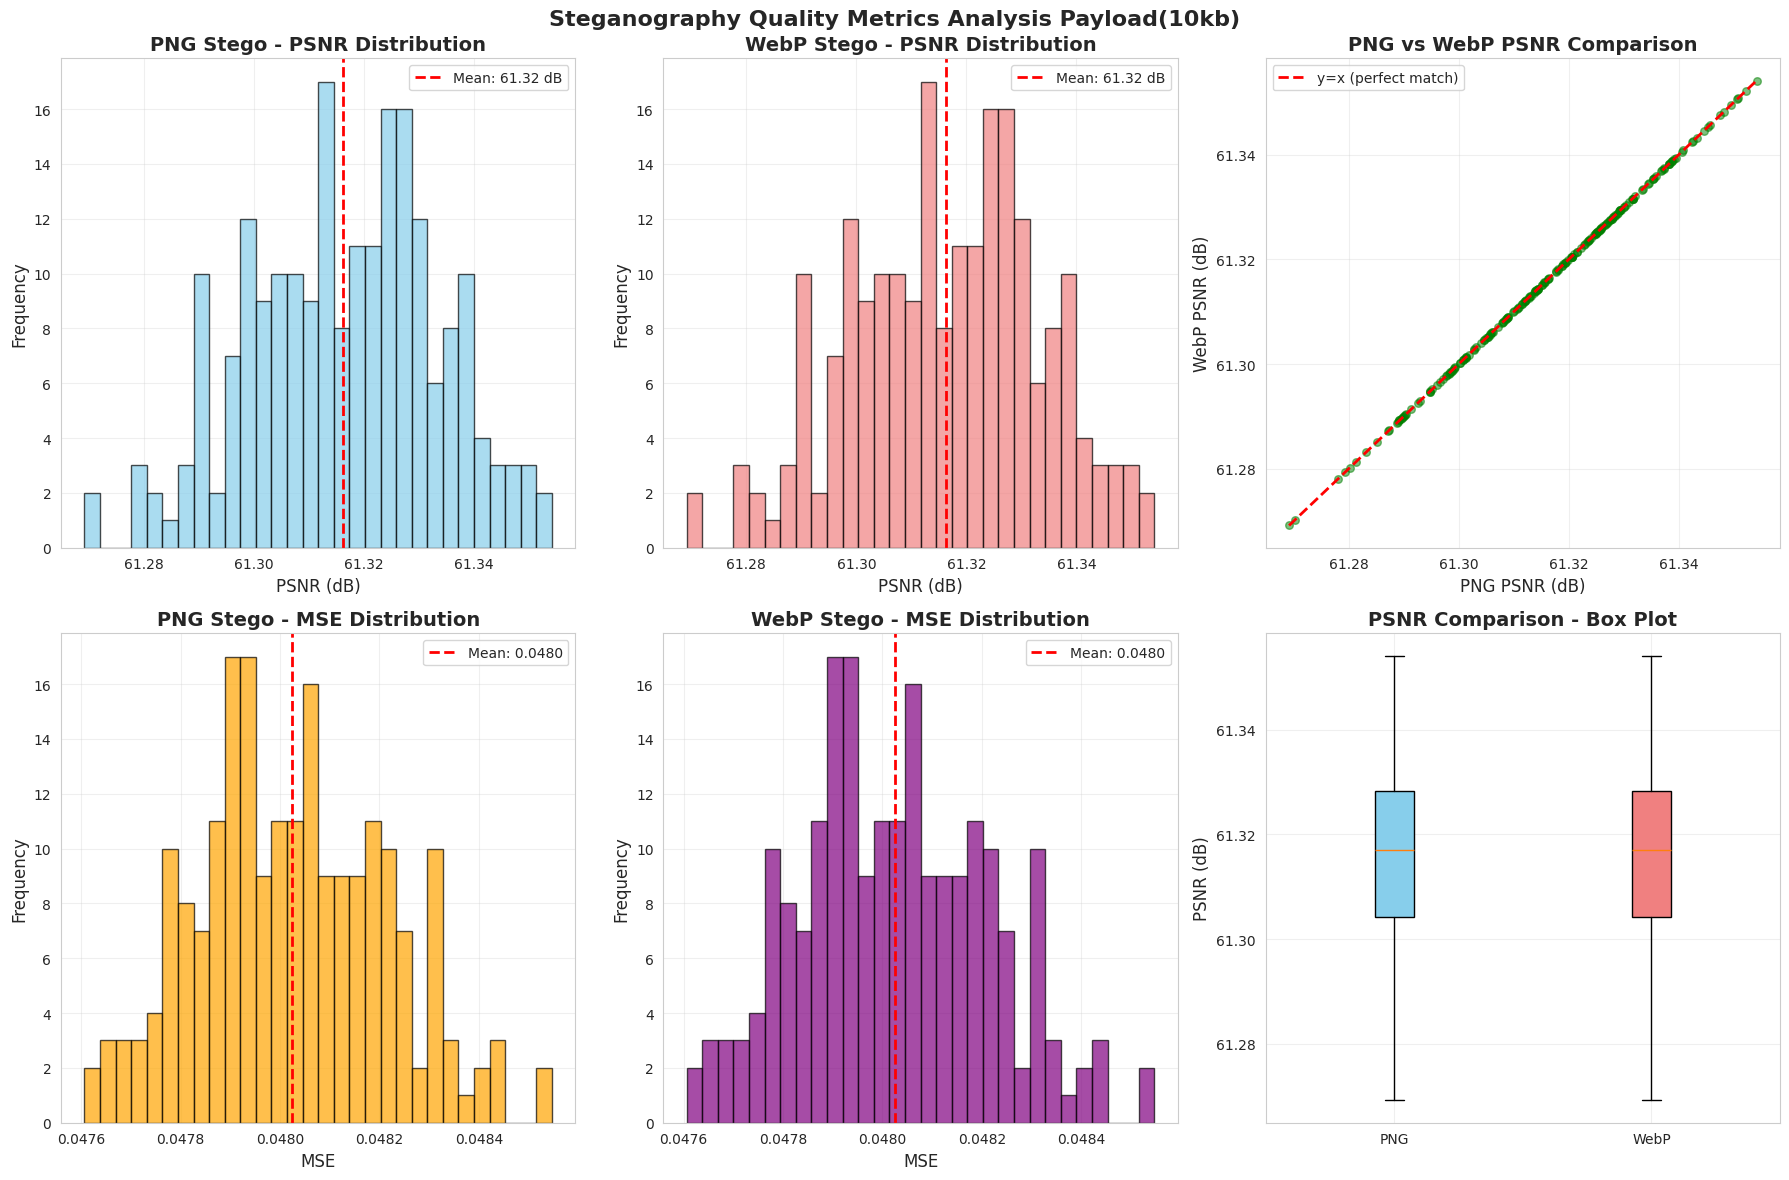

In [ ]:
# Cell 10: Visualize Quality Metrics
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 10)

# Create subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Steganography Quality Metrics Analysis Payload(10kb)', fontsize=16, fontweight='bold')

# 1. PSNR Distribution - PNG
axes[0, 0].hist(df['psnr_png'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(df['psnr_png'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["psnr_png"].mean():.2f} dB')
axes[0, 0].set_xlabel('PSNR (dB)', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].set_title('PNG Stego - PSNR Distribution', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# 2. PSNR Distribution - WebP
axes[0, 1].hist(df['psnr_webp'], bins=30, color='lightcoral', edgecolor='black', alpha=0.7)
axes[0, 1].axvline(df['psnr_webp'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["psnr_webp"].mean():.2f} dB')
axes[0, 1].set_xlabel('PSNR (dB)', fontsize=12)
axes[0, 1].set_ylabel('Frequency', fontsize=12)
axes[0, 1].set_title('WebP Stego - PSNR Distribution', fontsize=14, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# 3. PSNR Comparison (PNG vs WebP)
axes[0, 2].scatter(df['psnr_png'], df['psnr_webp'], alpha=0.5, s=30, color='green')
axes[0, 2].plot([df['psnr_png'].min(), df['psnr_png'].max()],
                [df['psnr_png'].min(), df['psnr_png'].max()],
                'r--', linewidth=2, label='y=x (perfect match)')
axes[0, 2].set_xlabel('PNG PSNR (dB)', fontsize=12)
axes[0, 2].set_ylabel('WebP PSNR (dB)', fontsize=12)
axes[0, 2].set_title('PNG vs WebP PSNR Comparison', fontsize=14, fontweight='bold')
axes[0, 2].legend()
axes[0, 2].grid(alpha=0.3)

# 4. MSE Distribution - PNG
axes[1, 0].hist(df['mse_png'], bins=30, color='orange', edgecolor='black', alpha=0.7)
axes[1, 0].axvline(df['mse_png'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["mse_png"].mean():.4f}')
axes[1, 0].set_xlabel('MSE', fontsize=12)
axes[1, 0].set_ylabel('Frequency', fontsize=12)
axes[1, 0].set_title('PNG Stego - MSE Distribution', fontsize=14, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# 5. MSE Distribution - WebP
axes[1, 1].hist(df['mse_webp'], bins=30, color='purple', edgecolor='black', alpha=0.7)
axes[1, 1].axvline(df['mse_webp'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["mse_webp"].mean():.4f}')
axes[1, 1].set_xlabel('MSE', fontsize=12)
axes[1, 1].set_ylabel('Frequency', fontsize=12)
axes[1, 1].set_title('WebP Stego - MSE Distribution', fontsize=14, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

# 6. Box Plot Comparison
data_to_plot = [df['psnr_png'], df['psnr_webp']]
box = axes[1, 2].boxplot(data_to_plot, labels=['PNG', 'WebP'], patch_artist=True)
box['boxes'][0].set_facecolor('skyblue')
box['boxes'][1].set_facecolor('lightcoral')
axes[1, 2].set_ylabel('PSNR (dB)', fontsize=12)
axes[1, 2].set_title('PSNR Comparison - Box Plot', fontsize=14, fontweight='bold')
axes[1, 2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('./quality_metrics_visualization_very_large.png', dpi=300, bbox_inches='tight')
print("📊 Visualization saved to: ./quality_metrics_visualization_very_large.png")
plt.show()

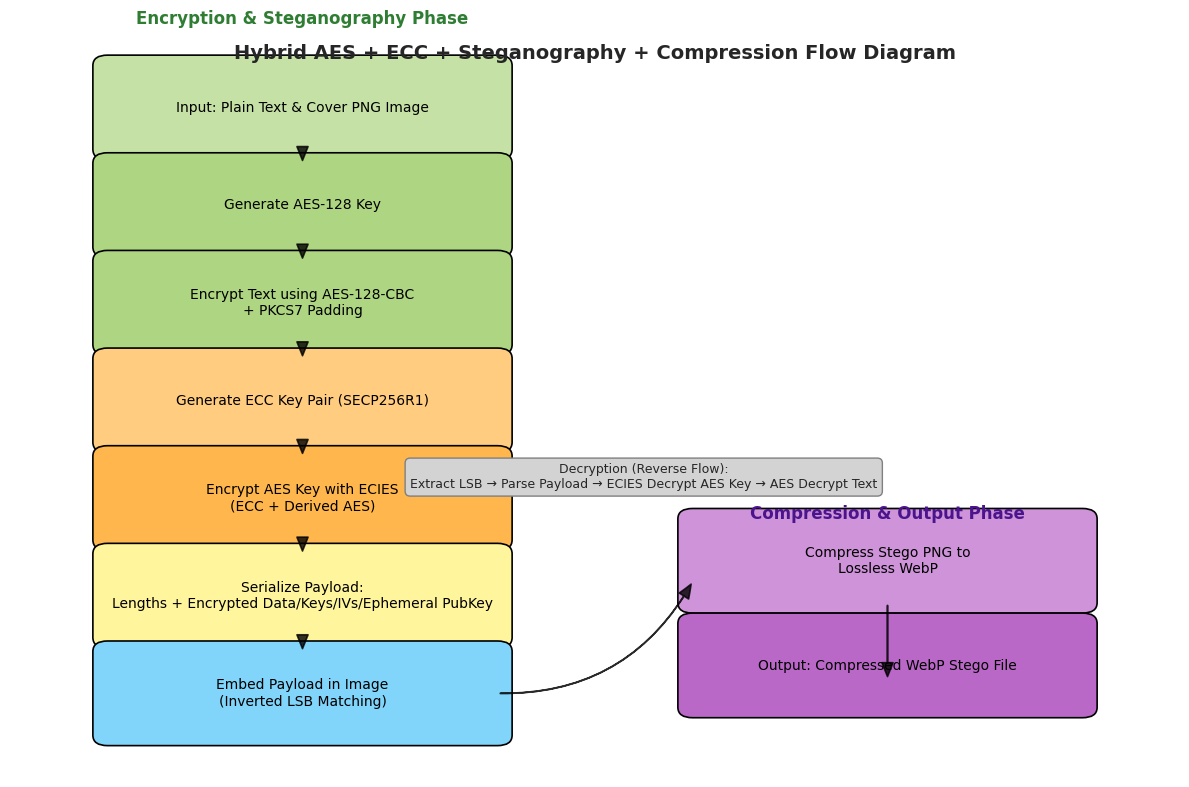

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import FancyArrowPatch

# Create figure
fig, ax = plt.subplots(figsize=(12, 8))
ax.set_xlim(0, 12)
ax.set_ylim(0, 11)
ax.axis('off')

# --- Helper to draw boxes ---
def add_box(x, y, text, color="#B3E5FC", width=4, height=1.2, fontsize=10, text_color="black"):
    rect = patches.FancyBboxPatch(
        (x, y), width, height,
        boxstyle="round,pad=0.15",
        ec="black", fc=color, lw=1.2
    )
    ax.add_patch(rect)
    ax.text(x + width/2, y + height/2, text,
            ha='center', va='center', fontsize=fontsize, color=text_color, wrap=True)

# --- Boxes (Encryption Flow) ---
add_box(1, 9, "Input: Plain Text & Cover PNG Image", color="#C5E1A5")
add_box(1, 7.6, "Generate AES-128 Key", color="#AED581")
add_box(1, 6.2, "Encrypt Text using AES-128-CBC\n+ PKCS7 Padding", color="#AED581")
add_box(1, 4.8, "Generate ECC Key Pair (SECP256R1)", color="#FFCC80")
add_box(1, 3.4, "Encrypt AES Key with ECIES\n(ECC + Derived AES)", color="#FFB74D")
add_box(1, 2.0, "Serialize Payload:\nLengths + Encrypted Data/Keys/IVs/Ephemeral PubKey", color="#FFF59D")
add_box(1, 0.6, "Embed Payload in Image\n(Inverted LSB Matching)", color="#81D4FA")

# --- Boxes (Compression & Output) ---
add_box(7, 2.5, "Compress Stego PNG to\nLossless WebP", color="#CE93D8")
add_box(7, 1.0, "Output: Compressed WebP Stego File", color="#BA68C8")

# --- Title ---
ax.text(6, 10.3, "Hybrid AES + ECC + Steganography + Compression Flow Diagram",
        ha='center', fontsize=14, fontweight='bold')

# --- Decryption Note ---
ax.text(6.5, 4.3,
        "Decryption (Reverse Flow):\nExtract LSB → Parse Payload → ECIES Decrypt AES Key → AES Decrypt Text",
        ha='center', va='center',
        fontsize=9,
        bbox=dict(facecolor='lightgray', edgecolor='gray', boxstyle='round,pad=0.4'))

# --- Arrows ---
arrow_style = "simple,head_width=8,head_length=10"
arrow_kwargs = dict(connectionstyle="arc3,rad=0", color="black", lw=1.2, alpha=0.8)

y_positions = [9, 7.6, 6.2, 4.8, 3.4, 2.0, 0.6]
for i in range(len(y_positions)-1):
    ax.add_patch(FancyArrowPatch(
        (3, y_positions[i]), (3, y_positions[i+1]+1.2),
        arrowstyle=arrow_style, **arrow_kwargs
    ))

# Curve to compression
ax.add_patch(FancyArrowPatch(
    (5, 1.2), (7, 2.8),
    connectionstyle="arc3,rad=0.3",
    color="black", lw=1.2, arrowstyle=arrow_style, alpha=0.8
))
# Arrow to output
ax.add_patch(FancyArrowPatch(
    (9, 2.5), (9, 1.4),
    connectionstyle="arc3,rad=0",
    color="black", lw=1.2, arrowstyle=arrow_style, alpha=0.8
))

# --- Section Labels ---
ax.text(3, 10.8, "Encryption & Steganography Phase", ha='center', fontsize=12, fontweight='bold', color="#2E7D32")
ax.text(9, 3.7, "Compression & Output Phase", ha='center', fontsize=12, fontweight='bold', color="#4A148C")

# --- Save & Show ---
plt.tight_layout()
plt.savefig('clean_hybrid_flow.png', bbox_inches='tight', dpi=300)
plt.show()


In [ ]:
# Install Java (if not already installed)
!apt-get update -qq && apt-get install -y openjdk-11-jre-headless -qq

# Download StegExpose from the correct repo
!wget -q https://github.com/b3dk7/StegExpose/raw/master/StegExpose.jar -O StegExpose.jar

# Verify download
!ls -la StegExpose.jar  # Should show ~1.5MB file

# Analysis code
import subprocess
import glob
import pandas as pd
import os

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package java-common.
(Reading database ... 125082 files and directories currently installed.)
Preparing to unpack .../java-common_0.72build2_all.deb ...
Unpacking java-common (0.72build2) ...
Selecting previously unselected package libpcsclite1:amd64.
Preparing to unpack .../libpcsclite1_1.9.5-3ubuntu1_amd64.deb ...
Unpacking libpcsclite1:amd64 (1.9.5-3ubuntu1) ...
Selecting previously unselected package openjdk-11-jre-headless:amd64.
Preparing to unpack .../openjdk-11-jre-headless_11.0.28+6-1ubuntu1~22.04.1_amd64.deb ...
Unpacking openjdk-11-jre-headless:amd64 (11.0.28+6-1ubuntu1~22.04.1) ...
Selecting previously unselected package ca-certificates-java.
Preparing to unpack .../ca-certificates-java_20190909ubuntu1.2_all.deb ...
Unpacking ca-certificates-java (20190909u

In [ ]:
def analyse_png_folder(folder_path, speed='fast', threshold='0.2'):
    """
    Runs StegExpose on a folder that contains ONLY PNG images.
    Returns a DataFrame with columns: file, detected, verdict, output
    """
    jar = "StegExpose.jar"
    results = []

    # ---- sanity checks -------------------------------------------------
    if not os.path.isdir(folder_path):
        print(f"  [ERROR] Folder not found: {folder_path}")
        return pd.DataFrame()
    png_files = glob.glob(os.path.join(folder_path, "*.png"))
    if not png_files:
        print(f"  [WARN] No PNG files in {folder_path}")
        return pd.DataFrame()
    print(f"  → Found {len(png_files)} PNG files in {folder_path}")

    # ---- run StegExpose ------------------------------------------------
    cmd = ['java', '-jar', jar, folder_path, speed, threshold]
    try:
        out = subprocess.check_output(
            cmd, stderr=subprocess.STDOUT, text=True, timeout=300
        )
    except Exception as e:
        print(f"  [ERROR] StegExpose failed: {e}")
        out = ""

    lines = [l.strip() for l in out.splitlines() if l.strip()]

    # ---- parse structured CSV lines ------------------------------------
    for line in lines:
        if ',' not in line:
            continue
        parts = line.split(',')
        if len(parts) < 2:
            continue
        verdict = parts[-1].upper()
        if verdict not in ('POSITIVE', 'NEGATIVE', 'SUSPICIOUS'):
            continue

        filename = os.path.basename(parts[0])
        detected = verdict in ('POSITIVE', 'SUSPICIOUS')
        results.append({
            "file": filename,
            "detected": detected,
            "verdict": verdict,
            "output": line
        })

    # ---- fallback: no structured lines → mark all as clean ------------
    if not results:
        print(f"  [INFO] No structured output – assuming clean.")
        for f in png_files:
            results.append({
                "file": os.path.basename(f),
                "detected": False,
                "verdict": "UNKNOWN",
                "output": "No output from StegExpose"
            })

    df = pd.DataFrame(results)
    # guarantee the column exists
    if 'detected' not in df.columns:
        df['detected'] = False
    return df

# --------------------------------------------------------------
# 4. Define ONLY the PNG folders
# --------------------------------------------------------------
datasets = {
    "stego_dataset":        ["stego_dataset/stego_png"],
    "stego_large_dataset":  ["stego_dataset_large/stego_png"],
    "stego_medium_dataset": ["stego_dataset_medium/stego_png"],
    "stego_very_large_dataset": ["stego_dataset_very_large/stego_png"],
}

# --------------------------------------------------------------
# 5. Run analysis & store results
# --------------------------------------------------------------
global_summary = []

for ds_name, folders in datasets.items():
    print(f"\n=== ANALYSING {ds_name.upper()} ===")
    ds_frames = []

    for folder in folders:
        df = analyse_png_folder(folder, speed='fast', threshold='0.2')
        if df.empty:
            continue
        df["dataset"] = ds_name
        ds_frames.append(df)

    if not ds_frames:
        print("  [INFO] No PNG data processed for this dataset.")
        continue

    full_df = pd.concat(ds_frames, ignore_index=True)
    csv_name = f"{ds_name}_results.csv"
    full_df.to_csv(csv_name, index=False)
    print(f"  → Saved → {csv_name}")

    # ---- statistics (safe) -----------------------------------------
    total = len(full_df)
    detected = full_df['detected'].sum()
    rate = detected / total * 100
    print(f"  → Detection rate: {detected}/{total} = {rate:.2f}%")
    global_summary.append({
        "dataset": ds_name,
        "files": total,
        "detected": detected,
        "rate_%": rate
    })

# --------------------------------------------------------------
# 6. Global summary table
# --------------------------------------------------------------
print("\n" + "="*60)
print("GLOBAL PNG-ONLY SUMMARY")
print("="*60)
summary_df = pd.DataFrame(global_summary)
print(summary_df.to_string(index=False))
print("\nDetailed CSV files are in the file browser:")
for ds in datasets:
    print(f"  • {ds}_results.csv")


=== ANALYSING STEGO_DATASET ===
  → Found 210 PNG files in stego_dataset/stego_png
  [INFO] No structured output – assuming clean.
  → Saved → stego_dataset_results.csv
  → Detection rate: 0/210 = 0.00%

=== ANALYSING STEGO_LARGE_DATASET ===
  → Found 210 PNG files in stego_dataset_large/stego_png
  [INFO] No structured output – assuming clean.
  → Saved → stego_large_dataset_results.csv
  → Detection rate: 0/210 = 0.00%

=== ANALYSING STEGO_MEDIUM_DATASET ===
  → Found 210 PNG files in stego_dataset_medium/stego_png
  [INFO] No structured output – assuming clean.
  → Saved → stego_medium_dataset_results.csv
  → Detection rate: 0/210 = 0.00%

=== ANALYSING STEGO_VERY_LARGE_DATASET ===
  → Found 210 PNG files in stego_dataset_very_large/stego_png
  [INFO] No structured output – assuming clean.
  → Saved → stego_very_large_dataset_results.csv
  → Detection rate: 0/210 = 0.00%

GLOBAL PNG-ONLY SUMMARY
                 dataset  files  detected  rate_%
           stego_dataset    210      

**AVALANCHE EFFECT - Crypto metric**

In [ ]:
# COMPLETE AVALANCHE TEST — ALL 4 CATEGORIES (467 CLEAN IMAGES)
import os
import numpy as np
import pandas as pd
from tqdm import tqdm

COVER_DIR = "/content/usc_sipi_preprocessed"
print(f"Searching for clean images in: {COVER_DIR}")

# Select one of each message type
secret_msg = secret_messages[0]
medium_msg = medium_messages[0]     # ~1 KB
large_msg = large_messages[0]       # ~3 KB
very_large_msg = very_large_messages[3]  # ~10 KB (example)

def avalanche_ratio(a: bytes, b: bytes) -> float:
    """% of differing bytes between two ciphertexts"""
    if len(a) != len(b):
        return float('nan')
    return np.mean(np.frombuffer(a, 'u1') != np.frombuffer(b, 'u1')) * 100

image_files = [f for f in os.listdir(COVER_DIR) if f.lower().endswith('.png')]
print(f"Found {len(image_files)} clean PNG images.")

results = []

for img_file in tqdm(image_files, desc="Testing 210 images"):

    key1 = generate_aes_key()
    key2 = bytearray(key1); key2[0] ^= 1; key2 = bytes(key2)

    # --- SECRET MESSAGE ---
    iv1_s, ct1_s = aes_encrypt(secret_msg, key1)
    iv2_s, ct2_s = aes_encrypt(secret_msg, key2)
    aes_aval_secret = avalanche_ratio(ct1_s, ct2_s)

    # --- MEDIUM MESSAGE ---
    iv1_m, ct1_m = aes_encrypt(medium_msg, key1)
    iv2_m, ct2_m = aes_encrypt(medium_msg, key2)
    aes_aval_medium = avalanche_ratio(ct1_m, ct2_m)

    # --- LARGE MESSAGE ---
    iv1_l, ct1_l = aes_encrypt(large_msg, key1)
    iv2_l, ct2_l = aes_encrypt(large_msg, key2)
    aes_aval_large = avalanche_ratio(ct1_l, ct2_l)

    # --- VERY LARGE MESSAGE ---
    iv1_vl, ct1_vl = aes_encrypt(very_large_msg, key1)
    iv2_vl, ct2_vl = aes_encrypt(very_large_msg, key2)
    aes_aval_very_large = avalanche_ratio(ct1_vl, ct2_vl)

    # --- ECC (AES key as payload) ---
    _, pub = generate_ecc_key_pair()
    _, _, enc1 = ecies_encrypt(key1, pub)
    _, _, enc2 = ecies_encrypt(key2, pub)
    ecc_aval = avalanche_ratio(enc1, enc2)

    results.append({
        'image': img_file,
        'aes_aval_secret_%': aes_aval_secret,
        'aes_aval_medium_%': aes_aval_medium,
        'aes_aval_large_%': aes_aval_large,
        'aes_aval_very_large_%': aes_aval_very_large,
        'ecc_aval_%': ecc_aval
    })

df = pd.DataFrame(results)
df.to_csv("avalanche_all_categories.csv", index=False)

print("\n" + "="*70)
print("FINAL AVALANCHE RESULTS (210 CLEAN IMAGES)")
print("="*70)
summary = df[['aes_aval_secret_%', 'aes_aval_medium_%', 'aes_aval_large_%',
              'aes_aval_very_large_%', 'ecc_aval_%']].agg(['mean', 'std']).round(3)
print(summary)


Searching for clean images in: /content/usc_sipi_preprocessed
Found 210 clean PNG images.


Testing 210 images: 100%|██████████| 210/210 [00:00<00:00, 563.96it/s]



FINAL AVALANCHE RESULTS (210 CLEAN IMAGES)
      aes_aval_secret_%  aes_aval_medium_%  aes_aval_large_%  \
mean             99.583             99.604            99.610   
std               0.872              0.208             0.111   

      aes_aval_very_large_%  ecc_aval_%  
mean                 99.612      99.628  
std                   0.059       1.014  


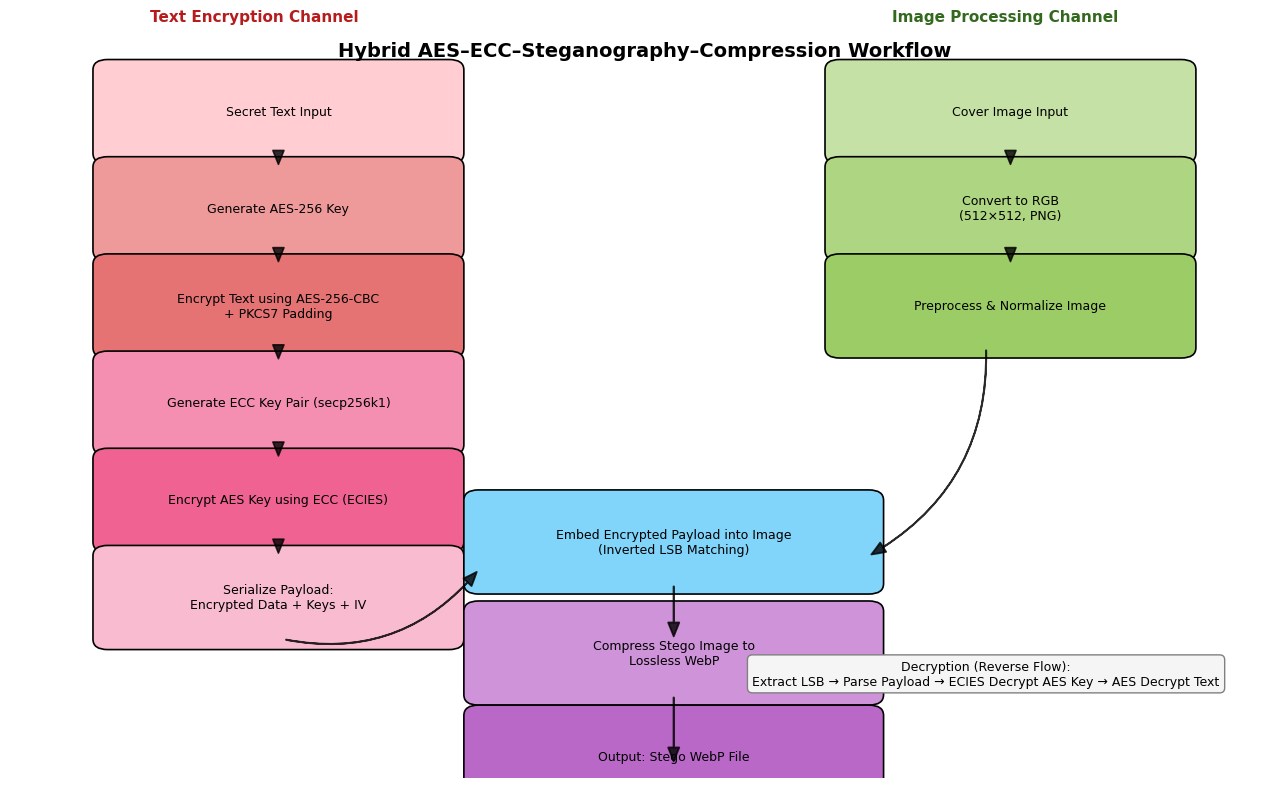

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import FancyArrowPatch

# --- Create figure ---
fig, ax = plt.subplots(figsize=(13, 8))
ax.set_xlim(0, 13)
ax.set_ylim(0, 11)
ax.axis('off')

# --- Helper to draw boxes ---
def add_box(x, y, text, color="#BBDEFB", width=3.5, height=1.2, fontsize=9, text_color="black"):
    rect = patches.FancyBboxPatch(
        (x, y), width, height,
        boxstyle="round,pad=0.15",
        ec="black", fc=color, lw=1.2
    )
    ax.add_patch(rect)
    ax.text(x + width/2, y + height/2, text,
            ha='center', va='center', fontsize=fontsize, color=text_color, wrap=True)

# === LEFT BRANCH — Secret Text Path (Encryption) ===
add_box(1, 9, "Secret Text Input", color="#FFCDD2")
add_box(1, 7.6, "Generate AES-256 Key", color="#EF9A9A")
add_box(1, 6.2, "Encrypt Text using AES-256-CBC\n+ PKCS7 Padding", color="#E57373")
add_box(1, 4.8, "Generate ECC Key Pair (secp256k1)", color="#F48FB1")
add_box(1, 3.4, "Encrypt AES Key using ECC (ECIES)", color="#F06292")
add_box(1, 2.0, "Serialize Payload:\nEncrypted Data + Keys + IV", color="#F8BBD0")

# === RIGHT BRANCH — Cover Image Path ===
add_box(8.5, 9, "Cover Image Input", color="#C5E1A5")
add_box(8.5, 7.6, "Convert to RGB\n(512×512, PNG)", color="#AED581")
add_box(8.5, 6.2, "Preprocess & Normalize Image", color="#9CCC65")

# === CENTER MERGE — LSB Embedding & Beyond ===
add_box(4.8, 2.8, "Embed Encrypted Payload into Image\n(Inverted LSB Matching)", color="#81D4FA", width=4)
add_box(4.8, 1.2, "Compress Stego Image to\nLossless WebP", color="#CE93D8", width=4)
add_box(4.8, -0.3, "Output: Stego WebP File", color="#BA68C8", width=4)

# === TITLES ===
ax.text(6.5, 10.4, "Hybrid AES–ECC–Steganography–Compression Workflow",
        ha='center', fontsize=14, fontweight='bold')
ax.text(2.5, 10.9, "Text Encryption Channel", ha='center', fontsize=11, fontweight='bold', color="#B71C1C")
ax.text(10.2, 10.9, "Image Processing Channel", ha='center', fontsize=11, fontweight='bold', color="#33691E")

# === Arrows: TEXT BRANCH ===
arrow_style = "simple,head_width=8,head_length=10"
arrow_kwargs = dict(connectionstyle="arc3,rad=0", color="black", lw=1.2, alpha=0.8)

y_positions_text = [9, 7.6, 6.2, 4.8, 3.4, 2.0]
for i in range(len(y_positions_text)-1):
    ax.add_patch(FancyArrowPatch(
        (2.75, y_positions_text[i]), (2.75, y_positions_text[i+1]+1.2),
        arrowstyle=arrow_style, **arrow_kwargs
    ))

# === Arrows: IMAGE BRANCH ===
y_positions_img = [9, 7.6, 6.2]
for i in range(len(y_positions_img)-1):
    ax.add_patch(FancyArrowPatch(
        (10.25, y_positions_img[i]), (10.25, y_positions_img[i+1]+1.2),
        arrowstyle=arrow_style, **arrow_kwargs
    ))

# === Merge Arrows into LSB Embedding ===
ax.add_patch(FancyArrowPatch(
    (2.8, 2.0), (4.8, 3.0),
    connectionstyle="arc3,rad=0.3",
    color="black", lw=1.3, arrowstyle=arrow_style, alpha=0.8
))
ax.add_patch(FancyArrowPatch(
    (10.0, 6.2), (8.8, 3.2),
    connectionstyle="arc3,rad=-0.3",
    color="black", lw=1.3, arrowstyle=arrow_style, alpha=0.8
))

# === Downstream Arrows ===
ax.add_patch(FancyArrowPatch(
    (6.8, 2.8), (6.8, 2.0),
    connectionstyle="arc3,rad=0",
    color="black", lw=1.3, arrowstyle=arrow_style, alpha=0.8
))
ax.add_patch(FancyArrowPatch(
    (6.8, 1.2), (6.8, 0.2),
    connectionstyle="arc3,rad=0",
    color="black", lw=1.3, arrowstyle=arrow_style, alpha=0.8
))

# === Decryption Note ===
ax.text(10, 1.5,
        "Decryption (Reverse Flow):\nExtract LSB → Parse Payload → ECIES Decrypt AES Key → AES Decrypt Text",
        ha='center', va='center', fontsize=9,
        bbox=dict(facecolor='whitesmoke', edgecolor='gray', boxstyle='round,pad=0.4'))

plt.tight_layout()
plt.savefig("hybrid_two_channel_flow.png", bbox_inches='tight', dpi=300)
plt.show()
